# 0 Příprava


In [1]:
# Importy
import os
import time
import textwrap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
from cleverminer import cleverminer

sns.set_theme(style="whitegrid")
CHARTS_DIR = "charts"


Cleverminer version  1.2.1


In [2]:
# Pomocné funkce

def wrap_labels(labels, width=35):
    return ['\n'.join(textwrap.wrap(str(label), width=width)) for label in labels]


def save_plot(name):
    os.makedirs(CHARTS_DIR, exist_ok=True)
    plt.tight_layout()
    plt.savefig(f"{CHARTS_DIR}/{name}.png", dpi=300, bbox_inches="tight")
    plt.show()


# 1 Načtení dat


In [3]:
path = "osoby_final.parquet"

df = pd.read_parquet(path, engine="fastparquet")

# 2 Oprava atributu věk (join)


In [4]:
# Join: doplnění vek z aktualizovaného datasetu
PATH_NEW = "osoby_final_last.parquet"
join_columns = [
    "identifikacni_cislo", "vek", "vek_osoby", "pohlavi_osoby_vozidlo", "id_vozidla", "Unnamed: 0"
]

df_new = pd.read_parquet(PATH_NEW, engine="fastparquet", columns=join_columns)

counts_old = df["identifikacni_cislo"].value_counts()
counts_new = df_new["identifikacni_cislo"].value_counts()
merged_counts = counts_old.to_frame("old").join(counts_new.to_frame("new"), how="outer").fillna(0)
bad_ic = merged_counts[merged_counts["old"] != merged_counts["new"]].index
n_bad = df["identifikacni_cislo"].isin(bad_ic).sum()

df = df[~df["identifikacni_cislo"].isin(bad_ic)].copy()
df_new_c = df_new[~df_new["identifikacni_cislo"].isin(bad_ic)].copy()
print(f"Nehod s rozdílným počtem osob: {len(bad_ic)}, vyřazeno řádků: {n_bad}")

sort_cols_old = ["identifikacni_cislo"] + (["Unnamed: 0"] if "Unnamed: 0" in df.columns else [])
sort_cols_new = ["identifikacni_cislo"] + (["Unnamed: 0"] if "Unnamed: 0" in df_new_c.columns else [])
df = df.sort_values(sort_cols_old, kind="stable").reset_index(drop=True)
df_new_c = df_new_c.sort_values(sort_cols_new, kind="stable").reset_index(drop=True)

df["_person_idx"] = df.groupby("identifikacni_cislo").cumcount()
df_new_c["_person_idx"] = df_new_c.groupby("identifikacni_cislo").cumcount()

new_for_merge = df_new_c[[
    "identifikacni_cislo", "_person_idx", "vek",
    "vek_osoby", "pohlavi_osoby_vozidlo", "id_vozidla"
]].rename(columns={
    "vek_osoby": "_vek_osoby_new",
    "pohlavi_osoby_vozidlo": "_pohl_new",
    "id_vozidla": "_idv_new",
})

n_before = len(df)
df = df.merge(new_for_merge, on=["identifikacni_cislo", "_person_idx"], how="left")
assert len(df) == n_before, "Merge změnil počet řádků!"


Nehod s rozdílným počtem osob: 7178, vyřazeno řádků: 5


In [5]:
# Validace joinu: shoda sdílených atributů musí být 100 %
print("=== Validace joinu vek ===")

both = df.dropna(subset=["vek_osoby", "_vek_osoby_new"])
e1 = (both["vek_osoby"] == both["_vek_osoby_new"]).mean() * 100
print(f"  vek_osoby (old vs new): {e1:.6f} % shoda na {len(both):,} párech")

both = df.dropna(subset=["pohlavi_osoby_vozidlo", "_pohl_new"])
e2 = (both["pohlavi_osoby_vozidlo"] == both["_pohl_new"]).mean() * 100
print(f"  pohlavi_osoby_vozidlo: {e2:.6f} % shoda na {len(both):,} párech")

both = df.dropna(subset=["id_vozidla", "_idv_new"])
e3 = (both["id_vozidla"] == both["_idv_new"]).mean() * 100
print(f"  id_vozidla: {e3:.6f} % shoda na {len(both):,} párech")

assert e1 == 100.0 and e2 == 100.0 and e3 == 100.0, "VALIDACE SELHALA"
print(">>> Všechny sdílené validační atributy mají 100% shodu; merge je korektní.")


=== Validace joinu vek ===
  vek_osoby (old vs new): 100.000000 % shoda na 2,303,217 párech
  pohlavi_osoby_vozidlo: 100.000000 % shoda na 2,268,300 párech
  id_vozidla: 100.000000 % shoda na 2,333,150 párech
>>> Všechny sdílené validační atributy mají 100% shodu; merge je korektní.


In [6]:
# Úklid: odstranění starého vek_osoby, ošetření záporných hodnot, diskretizace
df = df.drop(columns=["_person_idx", "_vek_osoby_new", "_pohl_new", "_idv_new", "vek_osoby"])

n_neg = (df["vek"] < 0).sum()
df.loc[df["vek"] < 0, "vek"] = np.nan
print(f"Záporné hodnoty vek nahrazené NaN: {n_neg}")
print(f"NaN ve sloupci vek celkem: {df['vek'].isna().sum():,} ({df['vek'].isna().mean()*100:.2f} %)")

# Diskretizace vek do skupin
vek_order = ["do 24 let", "25–34", "35–44", "45–54", "55–64", "65+"]
bins = [-0.1, 24, 34, 44, 54, 64, 200]
df["vek_skupina"] = pd.cut(df["vek"], bins=bins, labels=vek_order)

print(f"\nVěk: median={df['vek'].median():.0f}, mean={df['vek'].mean():.1f} (řidiči: median={df[df['oznaceni_osoby_vozidlo']=='řidič']['vek'].median():.0f})")


Záporné hodnoty vek nahrazené NaN: 693
NaN ve sloupci vek celkem: 234,921 (9.18 %)

Věk: median=39, mean=40.1 (řidiči: median=41)


# 3 Čištění atributů


In [7]:
df = df.drop(columns=[
    "Unnamed: 0",
    "Unnamed: 14",
    "Unnamed: 21",
    "Unnamed: 38",
    "Unnamed: 9",
    "alkohol_u_chodce_pritomen",
    "cas",
    "charakteristika_vozidla",
    "chodec_na_osobnim_prepravniku",
    "chovani_chodce",
    "cislo_pozemni_komunikace",
    "d",
    "datum",
    "druh_drogy_u_chodce",
    "druh_krizujici_komunikace",
    "druh_pneumatik_na_vozidle",
    "druh_pohonu_paliva",
    "druh_zvere_zvirete",
    "e",
    "kategorie_chodce",
    "krok",
    "minuta",
    "mistni_uprava_prednosti_v_jizde",
    "misto_dopravni_nehody",
    "nasledky_chodec",
    "obec",
    "okres",
    "p14*100",
    "p2a_dt",
    "p3",
    "p33h",
    "p38",
    "p40",
    "p41",
    "p48b",
    "p59h",
    "p5b",
    "pohlavi",
    "pohlavi_osoby_chodce",
    "poskytnuti_prvni_pomoci",
    "reflexni_prvky_u_chodce",
    "rizeni_provozu_v_dobe_nehody",
    "rok",
    "rok_x",
    "rok_y",
    "situace_v_miste_nehody",
    "smer_jizdy_nebo_postaveni_vozidla",
    "specificka_mista_objekty_v_miste_nehody",
    "statni_prislusnost_stat",
    "stav_chodce",
    "stav_ridice",
    "typ",
    "udaje_o_vozidle",
    "unik_provoznich_prepravovanych_hmot",
    "utvar",
    "vek_chodce",
    "vnejsi_ovlivneni_ridice",
    "vozidlo_po_nehode",
    "zpusob_vyprosteni_osob_z_vozidla",
], errors="ignore")

print(df.shape)

(2558233, 47)


In [8]:
# přejmenování srozumitelných kódovaných atributů
df = df.rename(columns={
    "p55b": "nejvyssi_dosazene_vzdelani",
    "p56": "delka_ridicske_praxe",
})

In [9]:
# Doplnění chybějícího mapování
df["druh_pozemni_komunikace"] = df["druh_pozemni_komunikace"].replace(
    {0: "dálnice", "0": "dálnice", "0.0": "dálnice"}
)

# 4 Odvozené proměnné a transformace


In [10]:
# Dopočet času a odvozených kalendářních atributů
df["datum_dt"] = pd.to_datetime(
    df["den_mesic_rok"].astype(str).str.strip(),
    format="mixed",
    dayfirst=True,
    errors="coerce"
)

df["mesic"] = df["datum_dt"].dt.month.astype("Int64")
df["den_v_tydnu"] = df["datum_dt"].dt.dayofweek.astype("Int64")
df["den_nazev"] = df["den_v_tydnu"].map({
    0: "pondělí",
    1: "úterý",
    2: "středa",
    3: "čtvrtek",
    4: "pátek",
    5: "sobota",
    6: "neděle"
})

kraj_map = {
    0: "Praha", 1: "Středočeský", 2: "Jihočeský", 3: "Plzeňský",
    4: "Ústecký", 5: "Královéhradecký", 6: "Jihomoravský",
    7: "Moravskoslezský", 14: "Olomoucký", 15: "Zlínský",
    16: "Vysočina", 17: "Pardubický", 18: "Liberecký", 19: "Karlovarský"
}
df["kraj_nazev"] = df["kraj"].map(kraj_map)

df = df.drop(columns=["den_mesic_rok"], errors="ignore")

# Kontrola
print(df["datum_dt"].isna().mean())
print(df["mesic"].isna().mean())
print(df["den_v_tydnu"].isna().mean())
print("kraj_nazev available:", "kraj_nazev" in df.columns)
print("den_nazev available:", "den_nazev" in df.columns)


0.0
0.0
0.0
kraj_nazev available: True
den_nazev available: True


In [11]:
df["alkohol_u_vinika_skupina"] = df["alkohol_u_vinika_nehody_pritomen"].replace({
    "ne": "ne",
    "ano, do 0,24 ‰": "ano – nízká/střední hladina",
    "ano, 0,24–0,5 ‰": "ano – nízká/střední hladina",
    "ano, 0,5–0,8 ‰": "ano – nízká/střední hladina",
    "ano, 0,8–1,0 ‰": "ano – nízká/střední hladina",
    "ano, 1,0–1,5 ‰": "ano – vysoká hladina",
    "ano, 1,5 ‰ a více": "ano – vysoká hladina",
    "odmítnuto": "neověřeno",
    "nezjišťováno": "neověřeno",
    "neznámá hodnota (chybi ve výčtu, pravděpodobně omyl)": "neověřeno"
})

alkohol_order = [
    "ne",
    "ano – nízká/střední hladina",
    "ano – vysoká hladina",
    "neověřeno"
]


In [12]:
# Nevalidní hodina 25 → NaN
df.loc[df["hodina"] == 25, "hodina"] = np.nan

# Přepočet škod ze stokorun na Kč
df["celkova_hmotna_skoda_kc"] = df["celkova_hmotna_skoda_kc"] * 100
df["skoda_na_vozidle"] = df["skoda_na_vozidle"] * 100


In [13]:
# zavaznost_nehody (nehoda-level)
df["zavaznost_nehody"] = np.select(
    [
        df["usmrceno_osob"] > 0,
        df["tezce_zraneno_osob"] > 0,
        df["lehce_zraneno_osob"] > 0
    ],
    [
        "usmrcení",
        "těžké zranění",
        "lehké zranění"
    ],
    default="bez zranění"
)

severity_order = [
    "bez zranění",
    "lehké zranění",
    "těžké zranění",
    "usmrcení"
]

# nehoda_se_zranenim (binární cíl)
df["nehoda_se_zranenim"] = np.where(
    df["zavaznost_nehody"] != "bez zranění", "ano", "ne"
)

# Smyk
df["smyk_nazev"] = df["smyk"].map({
    0.0: "ne",
    1.0: "ano"
})
df.loc[df["smyk"] == 3.0, "smyk_nazev"] = "jiné / chyba"
smyk_order = ["ne", "ano", "jiné / chyba"]

# Počet zúčastněných vozidel
df["pocet_zucastnenych_vozidel_skupina"] = (
    df["pocet_zucastnenych_vozidel"]
    .map({1: "1 vozidlo", 2: "2 vozidla"})
    .fillna("3 a více")
)
vozidla_count_order = ["1 vozidlo", "2 vozidla", "3 a více"]

# Délka řidičské praxe -> číslo
df["delka_ridicske_praxe_num"] = (
    df["delka_ridicske_praxe"]
    .replace("XX", pd.NA)
    .astype("string")
    .str.strip()
    .replace("<NA>", pd.NA)
    .str.lstrip("0")
    .replace("", "0")
)
df["delka_ridicske_praxe_num"] = pd.to_numeric(
    df["delka_ridicske_praxe_num"],
    errors="coerce"
)

praxe_bins = [-1, 1, 5, 10, 20, 100]
praxe_labels = [
    "do 1 roku",
    "2–5 let",
    "6–10 let",
    "11–20 let",
    "21 let a více"
]

df["praxe_skupina"] = pd.cut(
    df["delka_ridicske_praxe_num"],
    bins=praxe_bins,
    labels=praxe_labels
)

praxe_order = praxe_labels


In [14]:
# Seskupení high-cardinality kategorií → _skupina (původní sloupce ponechány)

# 1) hlavni_priciny_nehody → pricina_skupina
_pricina_map = {
    "bezohledná, agresivní jízda": "nesprávný způsob jízdy",
    "jízda po nesprávné straně vozovky": "nesprávný způsob jízdy",
    "vyhýbání bez dostatečného bočního odstupu": "nesprávný způsob jízdy",
    "jiný druh nesprávného způsobu jízdy": "nesprávný způsob jízdy",
    "vjetí na nezpevněnou komunikaci": "nesprávný způsob jízdy",
    "jízda jednosměrkou v protisměru": "nesprávný způsob jízdy",
    "samovolné rozjetí nezajištěného vozidla": "nesprávný způsob jízdy",
    "nesprávné otáčení nebo couvání": "nesprávný způsob jízdy",
    "jízda na červenou": "nesprávný způsob jízdy",
    "nevěnování se řízení vozidla": "nesprávný způsob jízdy",
    "nedodržení bezpečné vzdálenosti": "nesprávný způsob jízdy",
    "náhlé bezdůvodné brzdění nebo zastavení": "nesprávný způsob jízdy",
    "chyby při udání směru jízdy": "nesprávný způsob jízdy",
    "jiný nesprávný způsob jízdy": "nesprávný způsob jízdy",
    "nepřizpůsobení rychlosti stavu vozovky": "nepřiměřená rychlost",
    "nepřizpůsobení rychlosti dopravně technickému stavu vozovky": "nepřiměřená rychlost",
    "nepřizpůsobení rychlosti intenzitě provozu": "nepřiměřená rychlost",
    "nepřizpůsobení rychlosti vlastnostem vozidla a nákladu": "nepřiměřená rychlost",
    "jiný druh nepřiměřené rychlosti": "nepřiměřená rychlost",
    "nepřizpůsobení rychlosti viditelnosti": "nepřiměřená rychlost",
    "překročení předepsané rychlosti stanovené pravidly": "nepřiměřená rychlost",
    "nepřizpůsobení rychlosti bočnímu větru": "nepřiměřená rychlost",
    "překročení rychlosti stanovené dopravní značkou": "nepřiměřená rychlost",
    "nedání přednosti – značka DEJ PŘEDNOST": "nedání přednosti",
    "nedání přednosti při odbočování vlevo": "nedání přednosti",
    "nedání přednosti při změně jízdního pruhu": "nedání přednosti",
    "nedání přednosti – značka STŮJ DEJ PŘEDNOST": "nedání přednosti",
    "nedání přednosti chodci na přechodu": "nedání přednosti",
    "nedání přednosti při vjíždění na silnici": "nedání přednosti",
    "nedání přednosti zprava": "nedání přednosti",
    "nedání přednosti při otáčení nebo couvání": "nedání přednosti",
    "jiné nedání přednosti": "nedání přednosti",
    "nedání přednosti vlevo souběžně jedoucímu vozidlu": "nedání přednosti",
    "nedání přednosti při zařazování do proudu": "nedání přednosti",
    "nedání přednosti protijedoucímu vozidlu při objíždění": "nedání přednosti",
    "nedání přednosti tramvaji při odbočování": "nedání přednosti",
    "ohrožení předjížděného při předjíždění": "nesprávné předjíždění",
    "ohrožení protijedoucího při předjíždění": "nesprávné předjíždění",
    "předjíždění vlevo odbočujícího vozidla": "nesprávné předjíždění",
    "přehlédnutí předjíždějícího vozidla": "nesprávné předjíždění",
    "předjíždění bez dostatečného bočního odstupu": "nesprávné předjíždění",
    "předjíždění vpravo": "nesprávné předjíždění",
    "předjíždění bez dostatečného rozhledu": "nesprávné předjíždění",
    "jiné nesprávné předjíždění": "nesprávné předjíždění",
    "přejetí podélné čáry při předjíždění": "nesprávné předjíždění",
    "předjíždění v místech zakázaných DZ": "nesprávné předjíždění",
    "bránění v předjíždění": "nesprávné předjíždění",
    "defekt pneumatiky (průraz, únik vzduchu)": "technická závada",
    "upadnutí/ztráta kola": "technická závada",
    "jiná technická závada": "technická závada",
    "závada provozní brzdy": "technická závada",
    "závada závěsu přívěsu": "technická závada",
    "závada řízení": "technická závada",
    "opotřebení běhounu pod mez": "technická závada",
    "lom závěsu kola, pružiny": "technická závada",
    "zablokování kol mechanickou závadou": "technická závada",
    "nezajištěná/poškozená bočnice": "technická závada",
    "nefunkční parkovací brzda": "technická závada",
    "utržená spojovací hřídel": "technická závada",
    "nepřipojená/poškozená brzdová hadice přípojného vozidla": "technická závada",
    "závada osvětlovací soustavy": "technická závada",
    "nezaviněná řidičem": "nezaviněná řidičem",
    "nesprávné uložení nákladu": "ostatní",
    "nehoda při provádění služebního zákroku": "ostatní",
    "použití vozidla neoprávněnou osobou": "ostatní",
    "nehoda v důsledku použití služební zbraně (policií)": "ostatní",
}

df["pricina_skupina"] = df["hlavni_priciny_nehody"].map(_pricina_map).fillna("ostatní")

pricina_order = [
    "nesprávný způsob jízdy",
    "nepřiměřená rychlost",
    "nedání přednosti",
    "nesprávné předjíždění",
    "nezaviněná řidičem",
    "technická závada",
    "ostatní",
]


# 2) druh_vozidla → druh_vozidla_skupina
def _map_druh_vozidla(val):
    if pd.isna(val):
        return "nezjištěno"
    s = str(val)
    if "osobní automobil" in s:
        return "osobní automobil"
    if "nákladní automobil" in s:
        return "nákladní automobil"
    if "motocykl" in s:
        return "motocykl"
    if "jízdní kolo" in s or "koloběžka" in s:
        return "jízdní kolo / koloběžka"
    if "autobus" in s or "trolejbus" in s:
        return "autobus"
    if "tramvaj" in s or "vlak" in s:
        return "MHD / kolejové"
    if "nezjištěno" in s:
        return "nezjištěno"
    try:
        float(s)
        return "nezjištěno"
    except ValueError:
        return "ostatní"

df["druh_vozidla_skupina"] = df["druh_vozidla"].apply(_map_druh_vozidla)

druh_vozidla_order = [
    "osobní automobil",
    "nákladní automobil",
    "motocykl",
    "jízdní kolo / koloběžka",
    "autobus",
    "MHD / kolejové",
    "ostatní",
    "nezjištěno",
]

# 4) druh_srazky_jedoucich_vozidel: sloučení "z boku" a "boční"
df["druh_srazky_jedoucich_vozidel"] = (
    df["druh_srazky_jedoucich_vozidel"]
    .replace({"z boku": "boční"})
)



In [15]:
# Diskretizace hodina → denni_doba
def _map_denni_doba(h):
    if pd.isna(h) or h > 23:
        return None
    h = int(h)
    if h >= 23 or h <= 5:
        return "noc"
    if 6 <= h <= 9:
        return "ranní špička"
    if 10 <= h <= 13:
        return "dopoledne"
    if 14 <= h <= 18:
        return "odpolední špička"
    return "večer"

df["denni_doba"] = df["hodina"].apply(_map_denni_doba).astype("string")
denni_doba_order = ["noc", "ranní špička", "dopoledne", "odpolední špička", "večer"]
print(df["denni_doba"].value_counts(dropna=False))


denni_doba
odpolední špička    831283
dopoledne           576040
ranní špička        480913
večer               281838
noc                 208150
<NA>                180009
Name: count, dtype: Int64


In [16]:
# Diskretizace mesic do 4 ročních období
obdobi_map = {
    12: "zima", 1: "zima", 2: "zima",
    3: "jaro", 4: "jaro", 5: "jaro",
    6: "léto", 7: "léto", 8: "léto",
    9: "podzim", 10: "podzim", 11: "podzim",
}
df["rocni_obdobi"] = df["mesic"].map(obdobi_map).astype("string")
rocni_obdobi_order = ["jaro", "léto", "podzim", "zima"]
print(df["rocni_obdobi"].value_counts(dropna=False))


rocni_obdobi
léto      690358
podzim    683057
jaro      610309
zima      574509
Name: count, dtype: Int64


# 5 Modelovací subsety


In [17]:
# Modelovací a analytické subsety podle úrovně granularity
df_driver = df[df["oznaceni_osoby_vozidlo"] == "řidič"].copy()
df_accidents = df.drop_duplicates(subset="identifikacni_cislo").copy()
df_person = df.copy()

print("Subsets updated. df_driver:", len(df_driver), "| df_accidents:", len(df_accidents))


Subsets updated. df_driver: 1802771 | df_accidents: 1475668


# 6 Explorační analýza (EDA)


In [18]:
day_order = ["pondělí", "úterý", "středa", "čtvrtek", "pátek", "sobota", "neděle"]
month_order = list(range(1, 13))
hour_order = list(range(24))


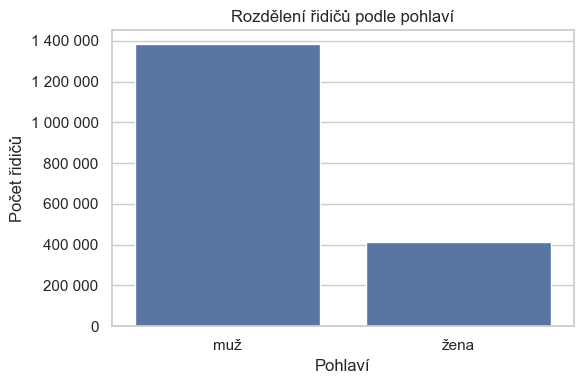

In [19]:
# jen dospělí řidiči
plt.figure(figsize=(6,4))

sns.countplot(
    data=df_driver[
        ~df_driver["pohlavi_osoby_vozidlo"].isin(["chlapec (do 15 let)", "dívka (do 15 let)"])
    ],
    x="pohlavi_osoby_vozidlo",
    order=["muž", "žena"]
)

plt.title("Rozdělení řidičů podle pohlaví")
plt.xlabel("Pohlaví")
plt.ylabel("Počet řidičů")

# lepší formát čísel na ose Y
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, p: f"{int(x):,}".replace(",", " "))
)

save_plot("Rozdělení řidičů podle pohlaví")

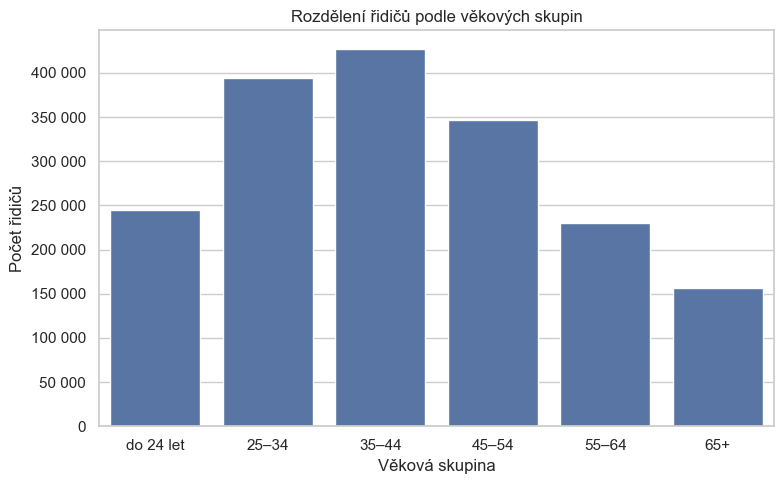

In [20]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df_driver,
    x="vek_skupina",
    order=vek_order
)

plt.title("Rozdělení řidičů podle věkových skupin")
plt.xlabel("Věková skupina")
plt.ylabel("Počet řidičů")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, p: f"{int(x):,}".replace(",", " "))
)

save_plot("Rozdělení řidičů podle věkových skupin")

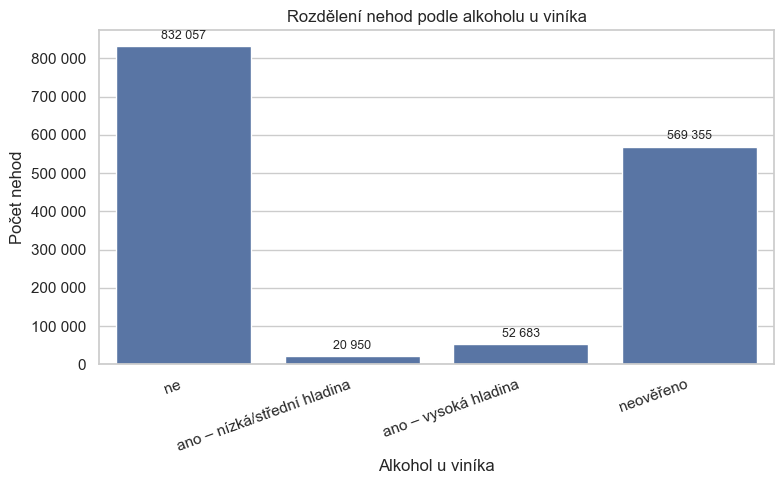

In [21]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=df_accidents,
    x="alkohol_u_vinika_skupina",
    order=alkohol_order
)

plt.title("Rozdělení nehod podle alkoholu u viníka")
plt.xlabel("Alkohol u viníka")
plt.ylabel("Počet nehod")
plt.xticks(rotation=20, ha="right")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, p: f"{int(x):,}".replace(",", " "))
)

# popisky nad sloupci
for container in ax.containers:
    ax.bar_label(
        container,
        fmt=lambda x: f"{int(x):,}".replace(",", " "),
        padding=3,
        fontsize=9
    )

save_plot("Rozdělení nehod podle alkoholu u viníka")

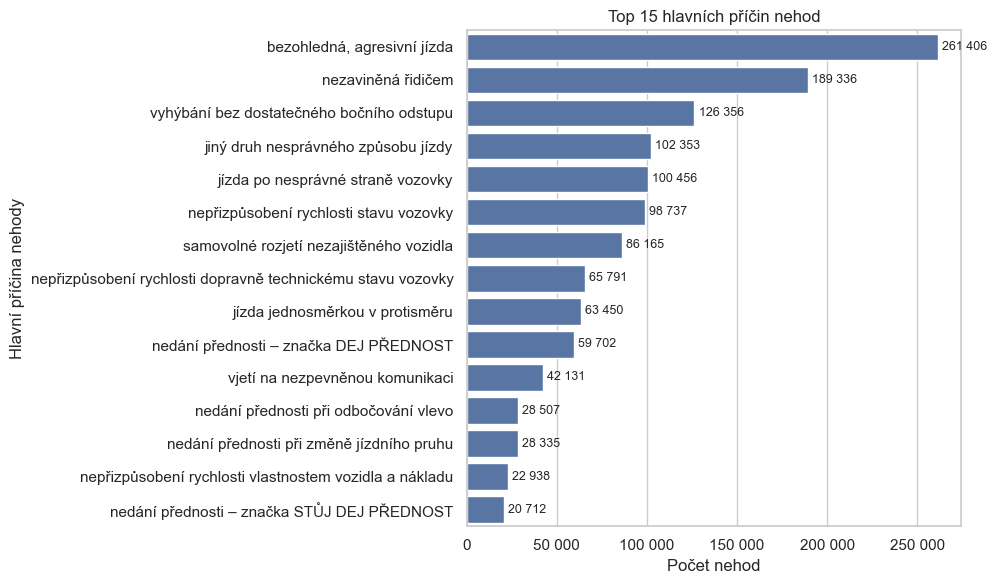

In [22]:
top_n = 15

top_priciny = df_accidents["hlavni_priciny_nehody"].value_counts().head(top_n).index

plt.figure(figsize=(10,6))

ax = sns.countplot(
    data=df_accidents,
    y="hlavni_priciny_nehody",
    order=top_priciny
)

plt.title(f"Top {top_n} hlavních příčin nehod")
plt.xlabel("Počet nehod")
plt.ylabel("Hlavní příčina nehody")

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, p: f"{int(x):,}".replace(",", " "))
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt=lambda x: f"{int(x):,}".replace(",", " "),
        padding=3,
        fontsize=9
    )

save_plot(f"Top {top_n} hlavních příčin nehod")

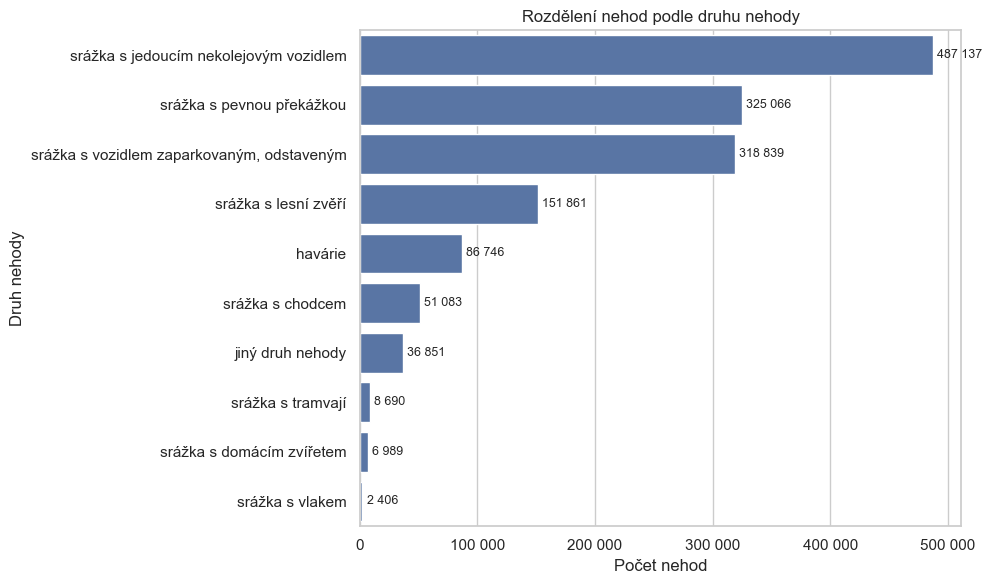

In [23]:
plt.figure(figsize=(10,6))

ax = sns.countplot(
    data=df_accidents,
    y="druh_nehody",
    order=df_accidents["druh_nehody"].value_counts().index
)

plt.title("Rozdělení nehod podle druhu nehody")
plt.xlabel("Počet nehod")
plt.ylabel("Druh nehody")

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, p: f"{int(x):,}".replace(",", " "))
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt=lambda x: f"{int(x):,}".replace(",", " "),
        padding=3,
        fontsize=9
    )

save_plot("Rozdělení nehod podle druhu nehody")

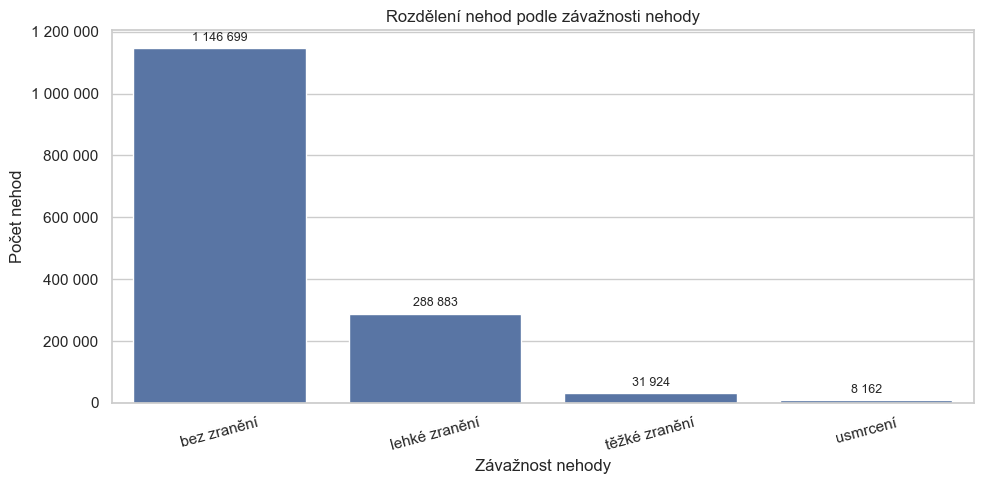

In [24]:
plt.figure(figsize=(10,5))

ax = sns.countplot(
    data=df_accidents,
    x="zavaznost_nehody",
    order=["bez zranění", "lehké zranění", "těžké zranění", "usmrcení"]
)

plt.title("Rozdělení nehod podle závažnosti nehody")
plt.xlabel("Závažnost nehody")
plt.ylabel("Počet nehod")
plt.xticks(rotation=15)

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, p: f"{int(x):,}".replace(",", " "))
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt=lambda x: f"{int(x):,}".replace(",", " "),
        padding=3,
        fontsize=9
    )

save_plot("Rozdělení nehod podle závažnosti nehody")


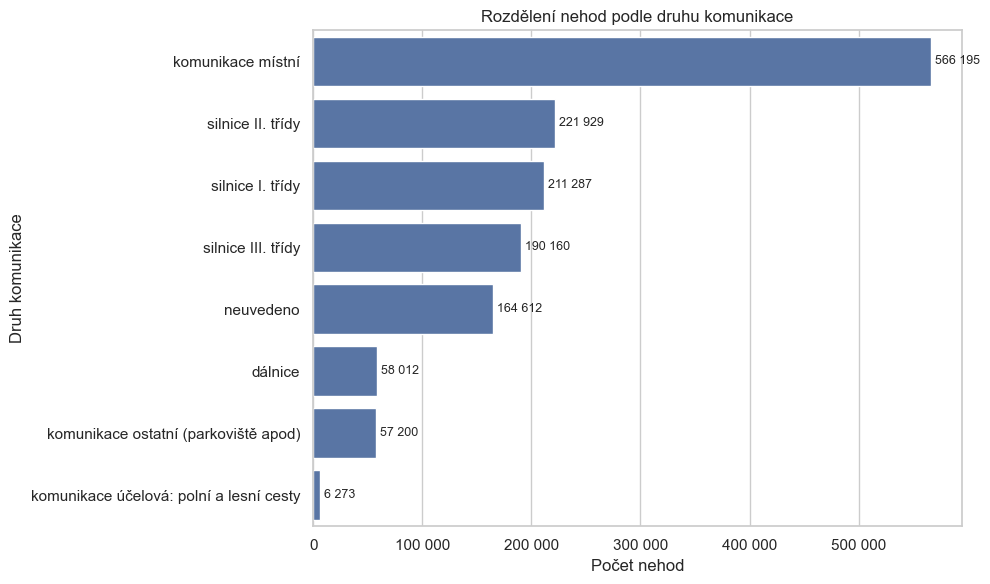

In [25]:
plt.figure(figsize=(10,6))

ax = sns.countplot(
    data=df_accidents,
    y="druh_pozemni_komunikace",
    order=df_accidents["druh_pozemni_komunikace"].value_counts().index
)

plt.title("Rozdělení nehod podle druhu komunikace")
plt.xlabel("Počet nehod")
plt.ylabel("Druh komunikace")

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, p: f"{int(x):,}".replace(",", " "))
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt=lambda x: f"{int(x):,}".replace(",", " "),
        padding=3,
        fontsize=9
    )

save_plot("Rozdělení nehod podle druhu komunikace")

### Person, driver, and accident profiles


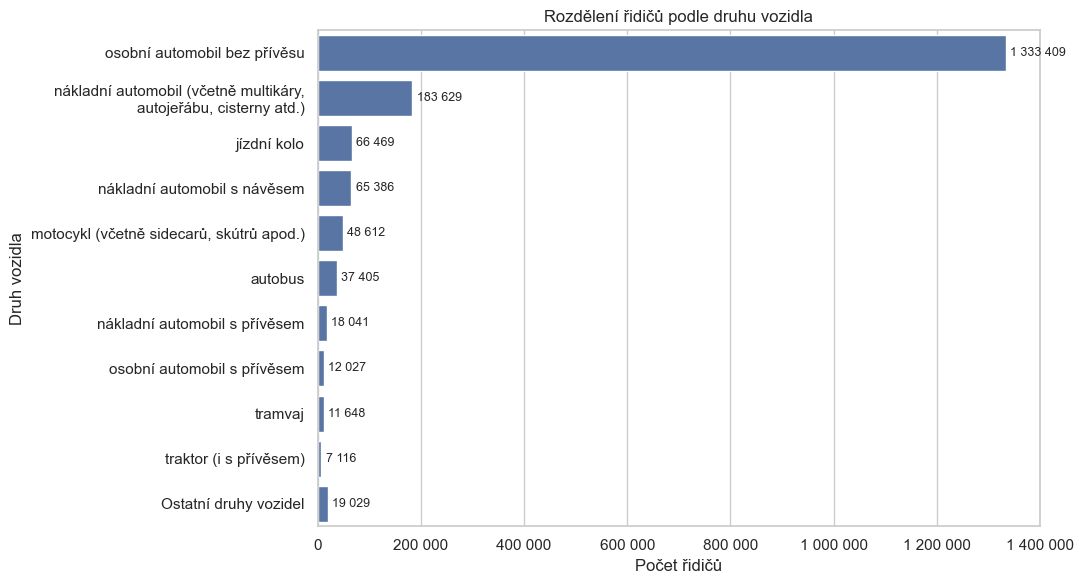

In [26]:
top_n = 10

druh_counts = df_driver["druh_vozidla"].value_counts()
top_druh = druh_counts.head(top_n)
ostatni = druh_counts.iloc[top_n:].sum()

druh_plot = pd.concat([
    top_druh,
    pd.Series({"Ostatní druhy vozidel": ostatni})
])

plt.figure(figsize=(11,6))

ax = sns.barplot(
    x=druh_plot.values,
    y=wrap_labels(druh_plot.index, width=40)
)

plt.title("Rozdělení řidičů podle druhu vozidla")
plt.xlabel("Počet řidičů")
plt.ylabel("Druh vozidla")

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, p: f"{int(x):,}".replace(",", " "))
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt=lambda x: f"{int(x):,}".replace(",", " "),
        padding=3,
        fontsize=9
    )

save_plot("Rozdělení řidičů podle druhu vozidla")

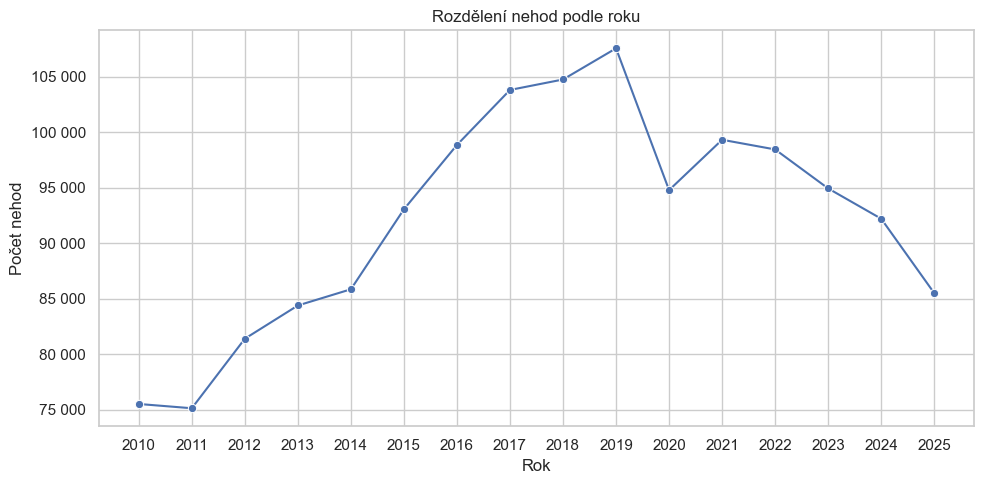

In [27]:
rok_counts = (
    df_accidents["rok_vypocten"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10,5))

sns.lineplot(
    x=rok_counts.index,
    y=rok_counts.values,
    marker="o"
)

plt.title("Rozdělení nehod podle roku")
plt.xlabel("Rok")
plt.ylabel("Počet nehod")
plt.xticks(rok_counts.index)

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, p: f"{int(x):,}".replace(",", " "))
)

save_plot("Rozdělení nehod podle roku")

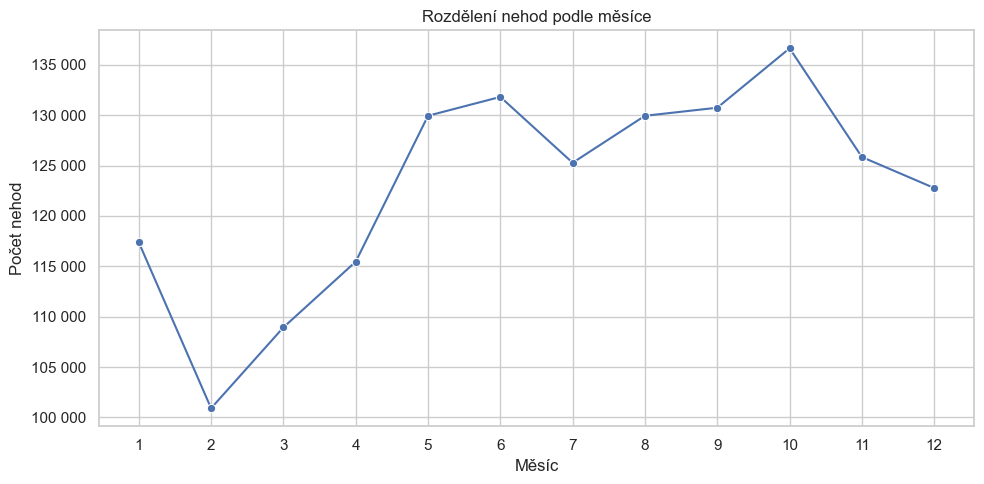

In [28]:
mesic_counts = (
    df_accidents["mesic"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10,5))

sns.lineplot(
    x=mesic_counts.index,
    y=mesic_counts.values,
    marker="o"
)

plt.title("Rozdělení nehod podle měsíce")
plt.xlabel("Měsíc")
plt.ylabel("Počet nehod")
plt.xticks(range(1, 13))

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, p: f"{int(x):,}".replace(",", " "))
)

save_plot("Rozdělení nehod podle měsíce")

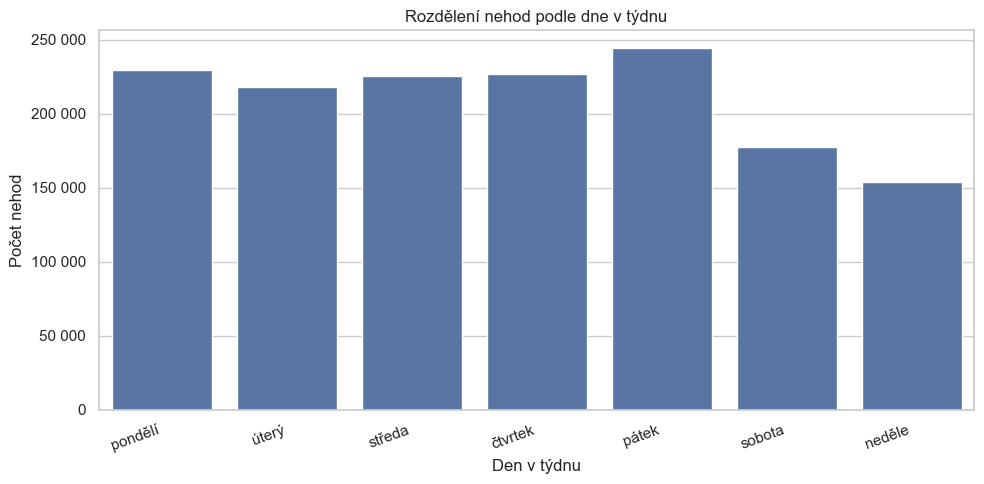

In [29]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df_accidents,
    x="den_nazev",
    order=day_order
)

plt.title("Rozdělení nehod podle dne v týdnu")
plt.xlabel("Den v týdnu")
plt.ylabel("Počet nehod")
plt.xticks(rotation=20, ha="right")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, p: f"{int(x):,}".replace(",", " "))
)

save_plot("Rozdělení nehod podle dne v týdnu")

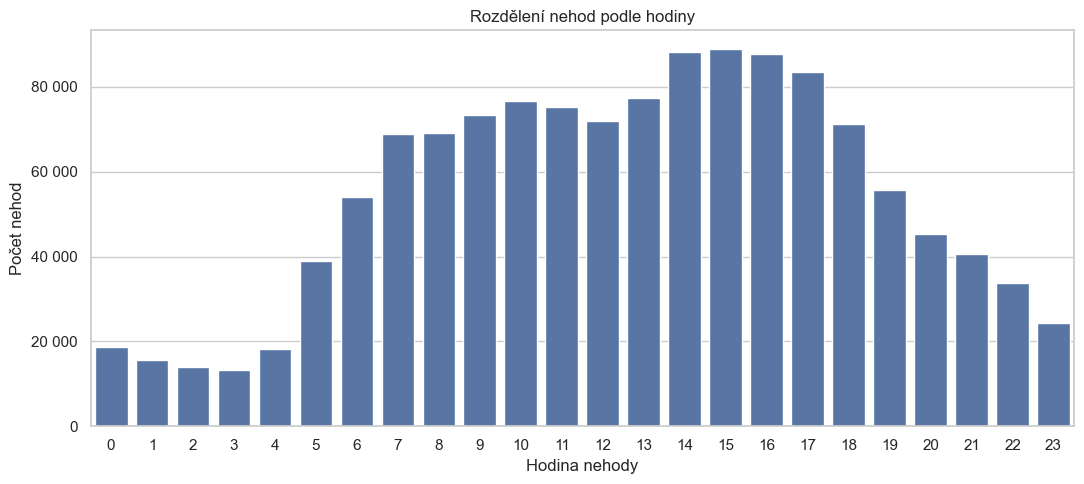

In [30]:
hodina_counts_valid = (
    df_accidents[df_accidents["hodina"] <= 23]["hodina"]
    .astype(int)
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(11,5))

sns.barplot(
    x=hodina_counts_valid.index,
    y=hodina_counts_valid.values
)

plt.title("Rozdělení nehod podle hodiny")
plt.xlabel("Hodina nehody")
plt.ylabel("Počet nehod")
plt.xticks(range(24))

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, p: f"{int(x):,}".replace(",", " "))
)

save_plot("Rozdělení nehod podle hodiny")

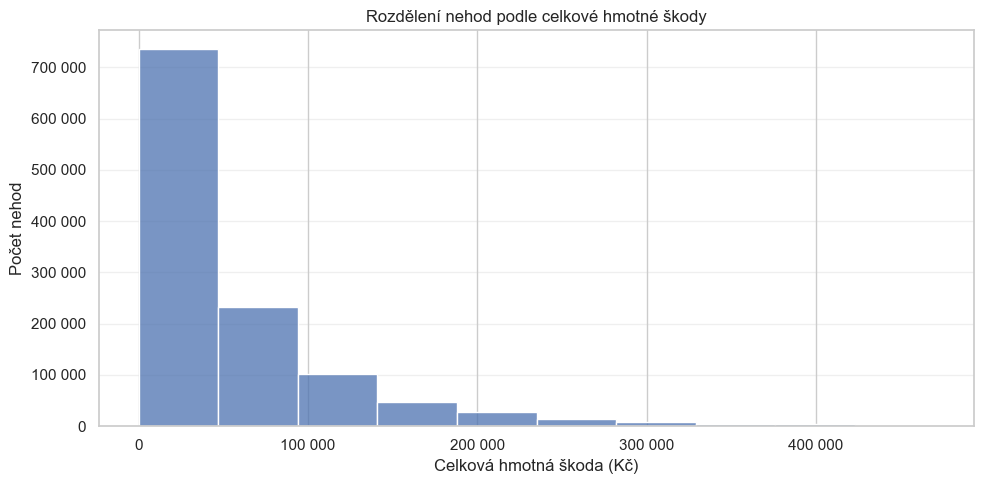

In [31]:
q99_hmotna = df_accidents["celkova_hmotna_skoda_kc"].quantile(0.99)

plt.figure(figsize=(10,5))

sns.histplot(
    data=df_accidents[df_accidents["celkova_hmotna_skoda_kc"] <= q99_hmotna],
    x="celkova_hmotna_skoda_kc",
    bins=10
)

plt.title("Rozdělení nehod podle celkové hmotné škody")
plt.xlabel("Celková hmotná škoda (Kč)")
plt.ylabel("Počet nehod")

plt.gca().xaxis.set_major_formatter(
    FuncFormatter(lambda x, p: f"{int(x):,}".replace(",", " "))
)
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, p: f"{int(x):,}".replace(",", " "))
)

plt.grid(axis="y", alpha=0.3)

save_plot("Rozdělení nehod podle celkové hmotné škody_bez_extremu")


### Bivariate analysis


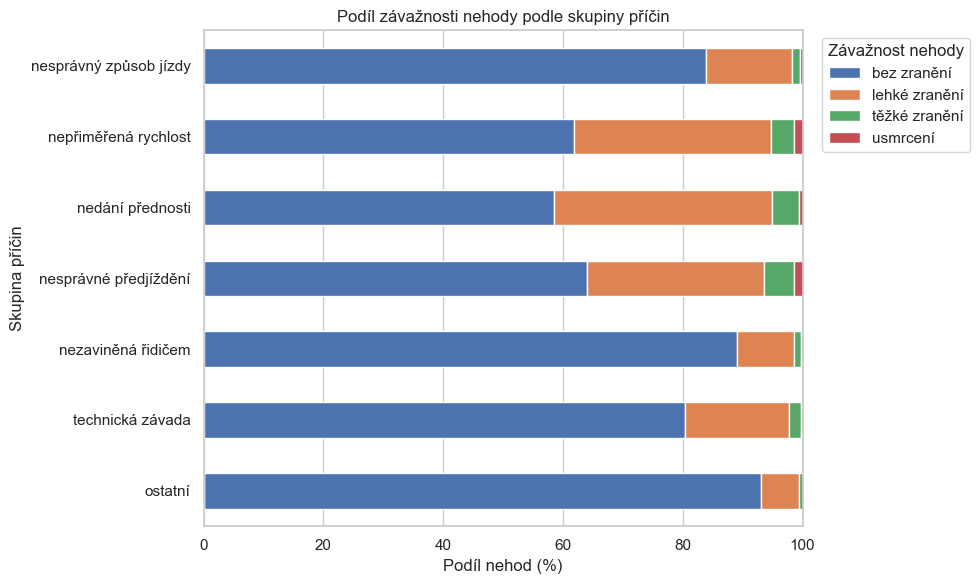

In [32]:
# Bivariační graf: pricina_skupina × závažnost nehody
ctab = pd.crosstab(df_accidents["pricina_skupina"], df_accidents["zavaznost_nehody"])
ctab = ctab.reindex(index=pricina_order, columns=severity_order, fill_value=0)
ctab = ctab.div(ctab.sum(axis=1), axis=0) * 100
ctab = ctab.iloc[::-1]

ax = ctab.plot(kind="barh", stacked=True, figsize=(10, 6))

plt.title("Podíl závažnosti nehody podle skupiny příčin")
plt.xlabel("Podíl nehod (%)")
plt.ylabel("Skupina příčin")
plt.xlim(0, 100)
plt.legend(title="Závažnost nehody", bbox_to_anchor=(1.02, 1), loc="upper left")

save_plot("Podíl závažnosti nehody podle skupiny příčin_horizontal")

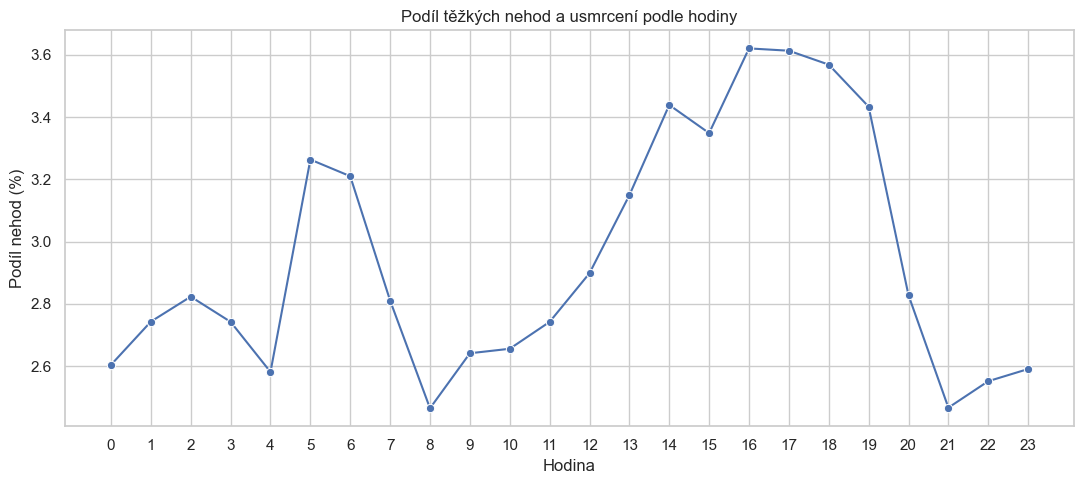

In [33]:
ctab = pd.crosstab(df_accidents["hodina"], df_accidents["zavaznost_nehody"])
ctab = ctab.reindex(index=hour_order, columns=severity_order, fill_value=0)

severe_share = (
    ctab[["těžké zranění", "usmrcení"]].sum(axis=1) / ctab.sum(axis=1) * 100
)

plt.figure(figsize=(11,5))

sns.lineplot(
    x=severe_share.index,
    y=severe_share.values,
    marker="o"
)

plt.title("Podíl těžkých nehod a usmrcení podle hodiny")
plt.xlabel("Hodina")
plt.ylabel("Podíl nehod (%)")
plt.xticks(hour_order)

save_plot("Podíl těžkých nehod a usmrcení podle hodiny_line")

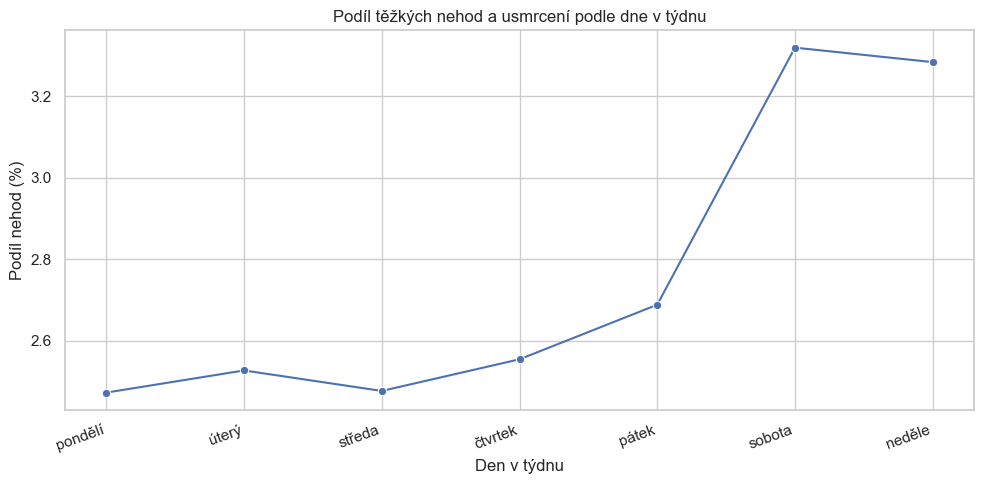

In [34]:
ctab = pd.crosstab(df_accidents["den_nazev"], df_accidents["zavaznost_nehody"])
ctab = ctab.reindex(index=day_order, columns=severity_order, fill_value=0)

severe_share = (
    ctab[["těžké zranění", "usmrcení"]].sum(axis=1) / ctab.sum(axis=1) * 100
)

plt.figure(figsize=(10,5))

sns.lineplot(
    x=severe_share.index,
    y=severe_share.values,
    marker="o"
)

plt.title("Podíl těžkých nehod a usmrcení podle dne v týdnu")
plt.xlabel("Den v týdnu")
plt.ylabel("Podíl nehod (%)")
plt.xticks(rotation=20, ha="right")

save_plot("Podíl těžkých nehod a usmrcení podle dne v týdnu_line")

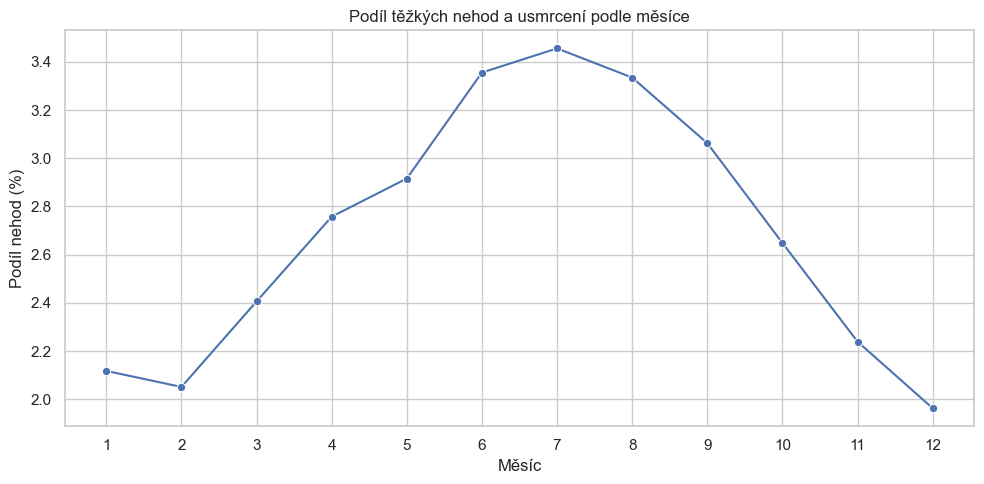

In [35]:
ctab = pd.crosstab(df_accidents["mesic"], df_accidents["zavaznost_nehody"])
ctab = ctab.reindex(index=month_order, columns=severity_order, fill_value=0)

severe_share = (
    ctab[["těžké zranění", "usmrcení"]].sum(axis=1) / ctab.sum(axis=1) * 100
)

plt.figure(figsize=(10,5))

sns.lineplot(
    x=severe_share.index,
    y=severe_share.values,
    marker="o"
)

plt.title("Podíl těžkých nehod a usmrcení podle měsíce")
plt.xlabel("Měsíc")
plt.ylabel("Podíl nehod (%)")
plt.xticks(month_order)

save_plot("Podíl těžkých nehod a usmrcení podle měsíce_line")

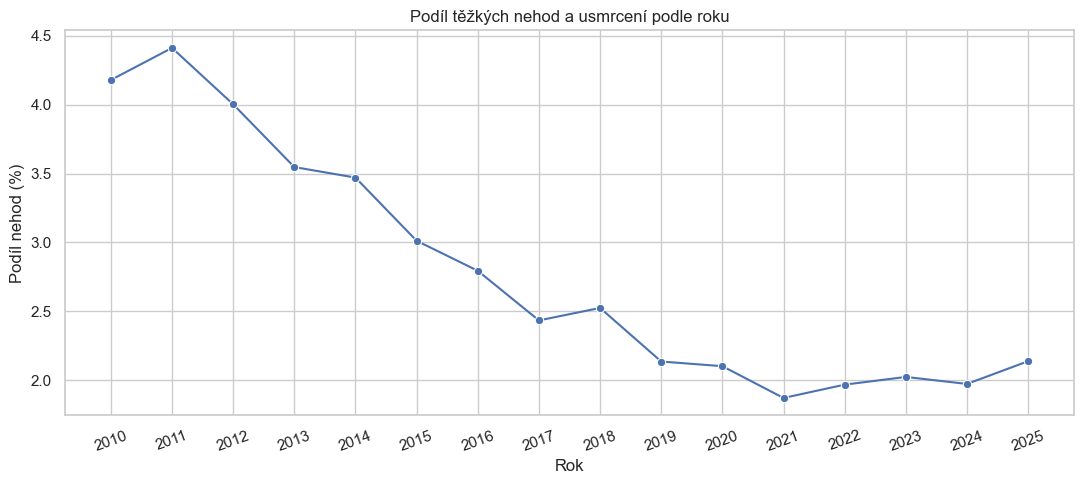

In [36]:
rok_order = sorted(df_accidents["rok_vypocten"].dropna().unique())

ctab = pd.crosstab(df_accidents["rok_vypocten"], df_accidents["zavaznost_nehody"])
ctab = ctab.reindex(index=rok_order, columns=severity_order, fill_value=0)

severe_share = (
    ctab[["těžké zranění", "usmrcení"]].sum(axis=1) / ctab.sum(axis=1) * 100
)

plt.figure(figsize=(11,5))

sns.lineplot(
    x=severe_share.index,
    y=severe_share.values,
    marker="o"
)

plt.title("Podíl těžkých nehod a usmrcení podle roku")
plt.xlabel("Rok")
plt.ylabel("Podíl nehod (%)")
plt.xticks(rok_order, rotation=20)

save_plot("Podíl těžkých nehod a usmrcení podle roku_line")

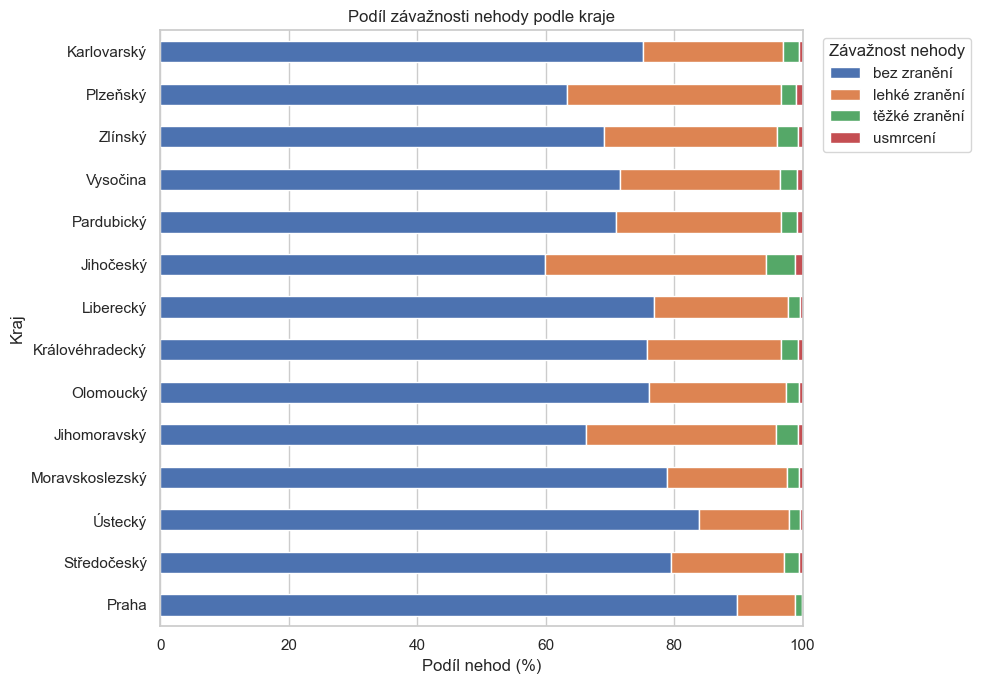

In [37]:
order = df_accidents["kraj_nazev"].value_counts().index

ctab = pd.crosstab(df_accidents["kraj_nazev"], df_accidents["zavaznost_nehody"])
ctab = ctab.reindex(index=order, columns=severity_order, fill_value=0)
ctab = ctab.div(ctab.sum(axis=1), axis=0) * 100
ctab.index = wrap_labels(ctab.index, width=22)

ax = ctab.plot(kind="barh", stacked=True, figsize=(10,7))

plt.title("Podíl závažnosti nehody podle kraje")
plt.xlabel("Podíl nehod (%)")
plt.ylabel("Kraj")
plt.xlim(0, 100)
plt.legend(title="Závažnost nehody", bbox_to_anchor=(1.02, 1), loc="upper left")

save_plot("Podíl závažnosti nehody podle kraje_horizontal")

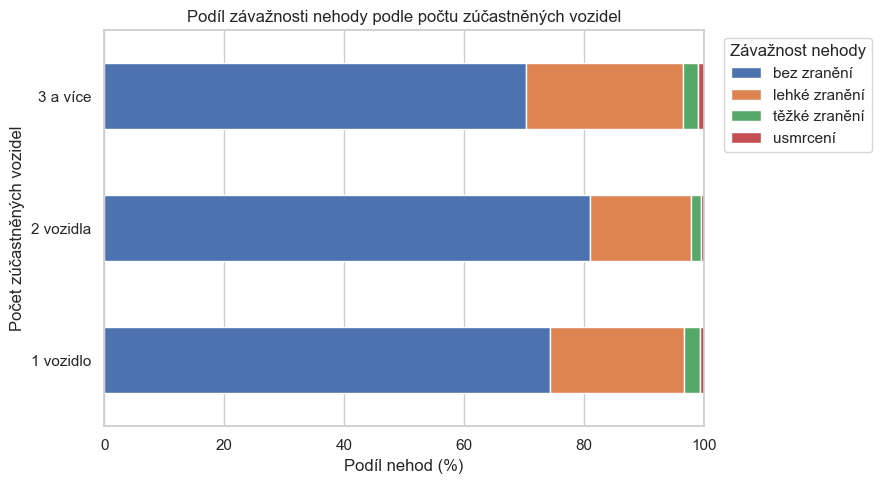

In [38]:
ctab = pd.crosstab(df_accidents["pocet_zucastnenych_vozidel_skupina"], df_accidents["zavaznost_nehody"])
ctab = ctab.reindex(index=vozidla_count_order, columns=severity_order, fill_value=0)
ctab = ctab.div(ctab.sum(axis=1), axis=0) * 100

ax = ctab.plot(kind="barh", stacked=True, figsize=(9,5))

plt.title("Podíl závažnosti nehody podle počtu zúčastněných vozidel")
plt.xlabel("Podíl nehod (%)")
plt.ylabel("Počet zúčastněných vozidel")
plt.xlim(0, 100)
plt.legend(title="Závažnost nehody", bbox_to_anchor=(1.02, 1), loc="upper left")

save_plot("Podíl závažnosti nehody podle počtu zúčastněných vozidel_horizontal")

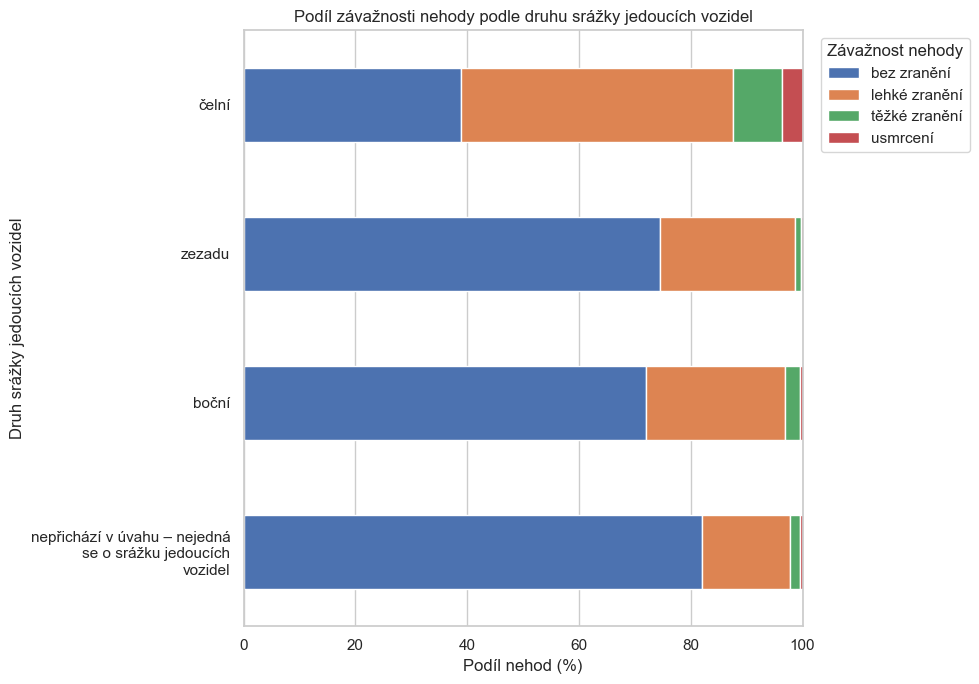

In [39]:
order = df_accidents["druh_srazky_jedoucich_vozidel"].value_counts().index

ctab = pd.crosstab(df_accidents["druh_srazky_jedoucich_vozidel"], df_accidents["zavaznost_nehody"])
ctab = ctab.reindex(index=order, columns=severity_order, fill_value=0)
ctab = ctab.div(ctab.sum(axis=1), axis=0) * 100
ctab.index = wrap_labels(ctab.index, width=28)

ax = ctab.plot(kind="barh", stacked=True, figsize=(10,7))

plt.title("Podíl závažnosti nehody podle druhu srážky jedoucích vozidel")
plt.xlabel("Podíl nehod (%)")
plt.ylabel("Druh srážky jedoucích vozidel")
plt.xlim(0, 100)
plt.legend(title="Závažnost nehody", bbox_to_anchor=(1.02, 1), loc="upper left")

save_plot("Podíl závažnosti nehody podle druhu srážky jedoucích vozidel_horizontal")

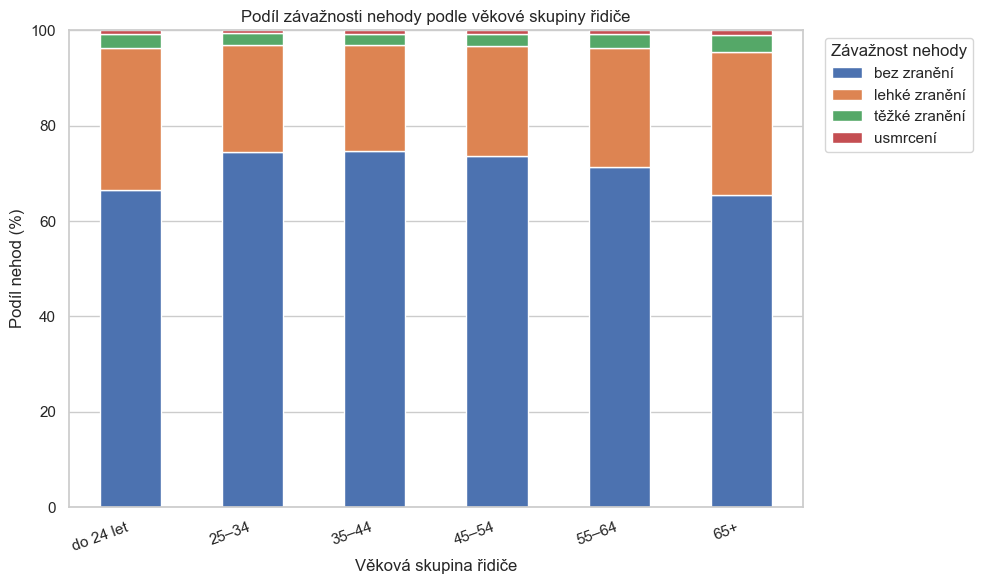

In [40]:
ctab = pd.crosstab(df_driver["vek_skupina"], df_driver["zavaznost_nehody"])
ctab = ctab.reindex(index=vek_order, columns=severity_order, fill_value=0)
ctab = ctab.div(ctab.sum(axis=1), axis=0) * 100

ax = ctab.plot(kind="bar", stacked=True, figsize=(10,6))

plt.title("Podíl závažnosti nehody podle věkové skupiny řidiče")
plt.xlabel("Věková skupina řidiče")
plt.ylabel("Podíl nehod (%)")
plt.xticks(rotation=20, ha="right")
plt.ylim(0, 100)
plt.legend(title="Závažnost nehody", bbox_to_anchor=(1.02, 1), loc="upper left")

save_plot("Podíl závažnosti nehody podle věkové skupiny řidiče")

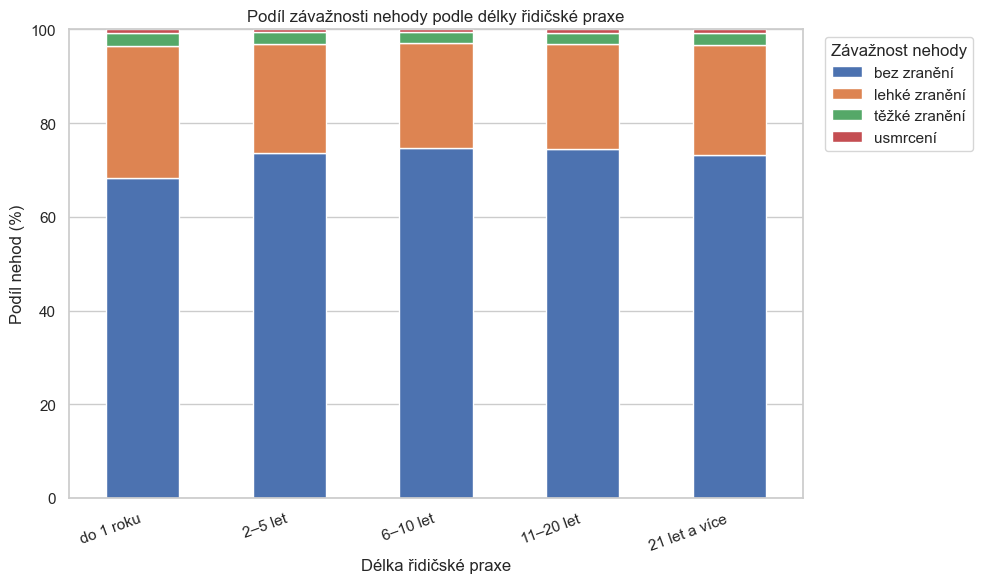

In [41]:
ctab = pd.crosstab(df_driver["praxe_skupina"], df_driver["zavaznost_nehody"])
ctab = ctab.reindex(index=praxe_order, columns=severity_order, fill_value=0)
ctab = ctab.div(ctab.sum(axis=1), axis=0) * 100

ax = ctab.plot(kind="bar", stacked=True, figsize=(10,6))

plt.title("Podíl závažnosti nehody podle délky řidičské praxe")
plt.xlabel("Délka řidičské praxe")
plt.ylabel("Podíl nehod (%)")
plt.xticks(rotation=20, ha="right")
plt.ylim(0, 100)
plt.legend(title="Závažnost nehody", bbox_to_anchor=(1.02, 1), loc="upper left")

save_plot("Podíl závažnosti nehody podle délky řidičské praxe")

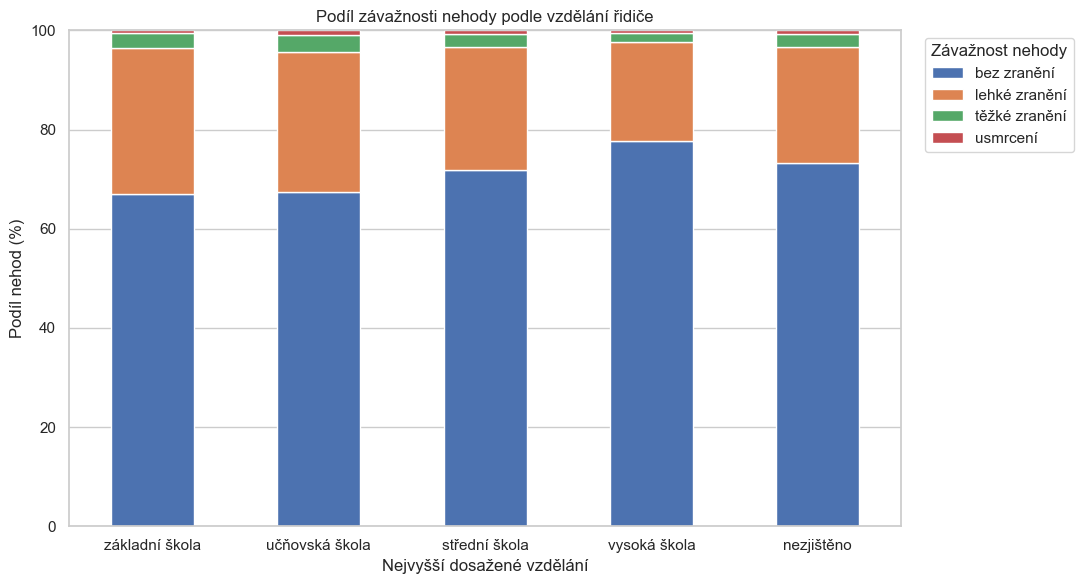

In [42]:
order = [
    "základní škola",
    "učňovská škola",
    "střední škola",
    "vysoká škola",
    "nezjištěno"
]

ctab = pd.crosstab(
    df_driver.loc[df_driver["nejvyssi_dosazene_vzdelani"].notna(), "nejvyssi_dosazene_vzdelani"],
    df_driver.loc[df_driver["nejvyssi_dosazene_vzdelani"].notna(), "zavaznost_nehody"]
)
ctab = ctab.reindex(index=order, columns=severity_order, fill_value=0)
ctab = ctab.div(ctab.sum(axis=1), axis=0) * 100

ax = ctab.plot(kind="bar", stacked=True, figsize=(11,6))

plt.title("Podíl závažnosti nehody podle vzdělání řidiče")
plt.xlabel("Nejvyšší dosažené vzdělání")
plt.ylabel("Podíl nehod (%)")
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.legend(title="Závažnost nehody", bbox_to_anchor=(1.02, 1), loc="upper left")

save_plot("Podíl závažnosti nehody podle vzdělání řidiče")

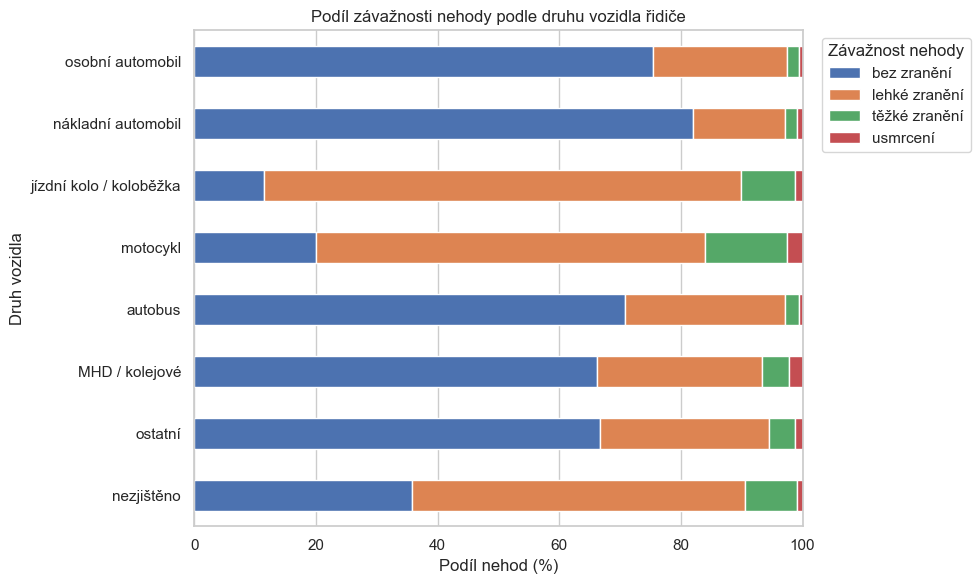

In [43]:
order = df_driver["druh_vozidla_skupina"].value_counts().index[::-1]

ctab = pd.crosstab(df_driver["druh_vozidla_skupina"], df_driver["zavaznost_nehody"])
ctab = ctab.reindex(index=order, columns=severity_order, fill_value=0)
ctab = ctab.div(ctab.sum(axis=1), axis=0) * 100
ctab.index = wrap_labels(ctab.index, width=28)

ax = ctab.plot(kind="barh", stacked=True, figsize=(10,6))

plt.title("Podíl závažnosti nehody podle druhu vozidla řidiče")
plt.xlabel("Podíl nehod (%)")
plt.ylabel("Druh vozidla")
plt.xlim(0, 100)
plt.legend(title="Závažnost nehody", bbox_to_anchor=(1.02, 1), loc="upper left")

save_plot("Podíl závažnosti nehody podle druhu vozidla řidiče_horizontal")

In [44]:
# Závažnost vozidla = max severity ze všech osob v daném (nehoda × vozidlo)
severity_rank = {
    "bez zranění": 0,
    "lehké zranění": 1,
    "těžké zranění": 2,
    "usmrcení": 3,
}
rank_to_severity = {v: k for k, v in severity_rank.items()}

df_person["_nasledky_rank"] = df_person["nasledky"].map(severity_rank)

zavaznost_vozidlo = (
    df_person.groupby(["identifikacni_cislo", "id_vozidla"])["_nasledky_rank"]
    .max()
    .map(rank_to_severity)
    .rename("zavaznost_vozidlo")
    .reset_index()
)

df_driver = df_driver.merge(
    zavaznost_vozidlo,
    on=["identifikacni_cislo", "id_vozidla"],
    how="left",
)

df_osobni = df_driver[df_driver["druh_vozidla_skupina"] == "osobní automobil"].copy()

In [45]:
# Prep: ctab + counts
top_n = 20
znacky_vc = df_osobni["vyrobni_znacka_motoroveho_vozidla"].value_counts()
znacky_text = znacky_vc[znacky_vc.index.str.match(r'^[A-Za-zÁ-žá-ž]', na=False)]
top_znacky = [z for z in znacky_text.head(top_n).index if z not in ["IVECO"]]

df_znacka = df_osobni[df_osobni["vyrobni_znacka_motoroveho_vozidla"].isin(top_znacky)].copy()
severity_order = ["bez zranění", "lehké zranění", "těžké zranění", "usmrcení"]

ctab = pd.crosstab(df_znacka["vyrobni_znacka_motoroveho_vozidla"],
                   df_znacka["zavaznost_vozidlo"], normalize="index") * 100
for col in severity_order:
    if col not in ctab.columns:
        ctab[col] = 0.0
ctab = ctab[severity_order]
ctab = ctab.sort_values("bez zranění", ascending=True)

counts = df_znacka["vyrobni_znacka_motoroveho_vozidla"].value_counts()

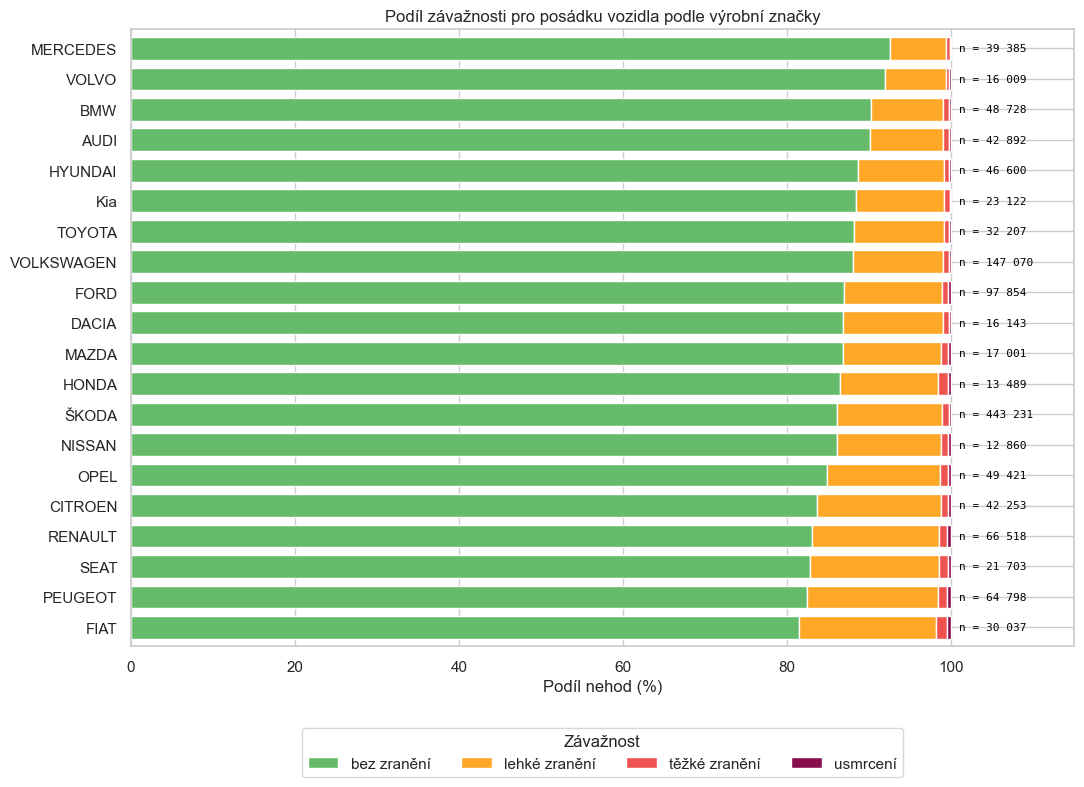

In [46]:
fig, ax = plt.subplots(figsize=(11, 8))
colors = ["#66BB6A", "#FFA726", "#EF5350", "#880E4F"]

ctab[severity_order].plot(kind="barh", stacked=True, ax=ax,
                          color=colors, width=0.75)

ax.set_xlabel("Podíl nehod (%)")
ax.set_ylabel("")
ax.set_title("Podíl závažnosti pro posádku vozidla podle výrobní značky")
ax.set_xlim(0, 115)
ax.legend(title="Závažnost", loc="upper center",
          bbox_to_anchor=(0.5, -0.12), ncol=4, frameon=True)

plt.subplots_adjust(bottom=0.15)


for i, znacka in enumerate(ctab.index):
    ax.text(101, i, f"n = {counts[znacka]:,}".replace(",", " "),
        va="center", fontsize=8, color="black",
        family="monospace")

plt.tight_layout()
plt.savefig("znacka_zavaznost_stacked.png", dpi=200, bbox_inches="tight")
plt.show()

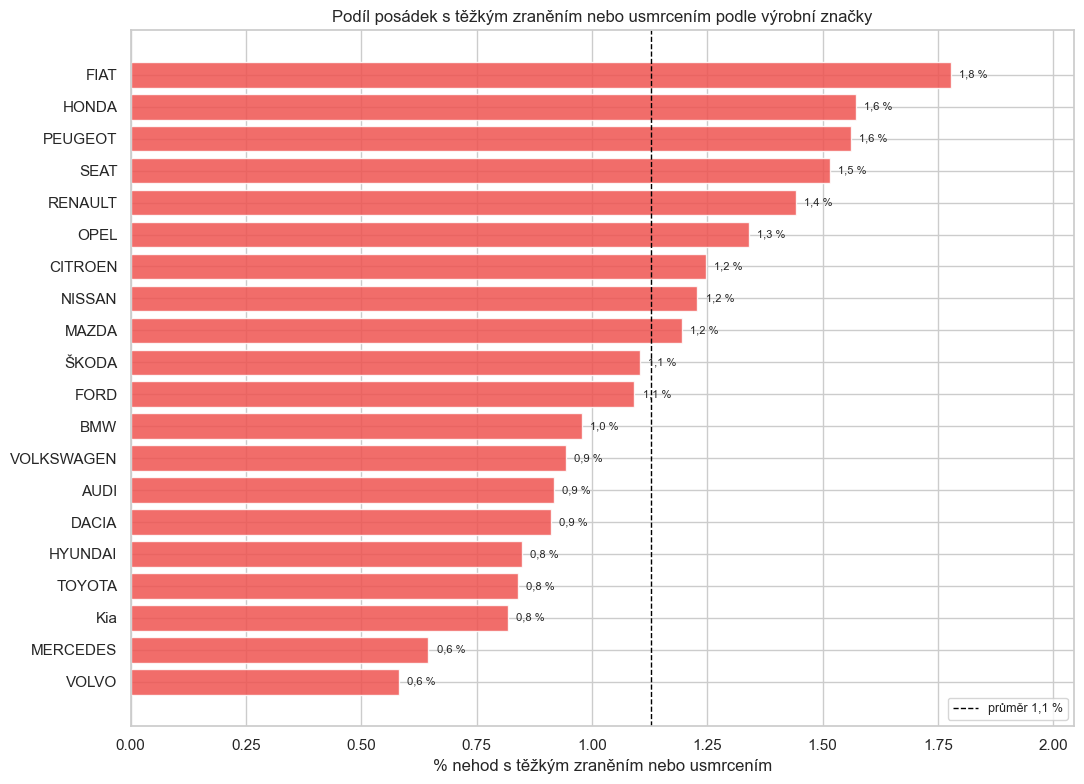

In [47]:
fig, ax = plt.subplots(figsize=(11, 8))
tezke = (ctab["těžké zranění"] + ctab["usmrcení"]).sort_values(ascending=True)

bars = ax.barh(tezke.index, tezke.values, color="#EF5350", alpha=0.85)

ax.set_xlabel("% nehod s těžkým zraněním nebo usmrcením")
ax.set_title("Podíl posádek s těžkým zraněním nebo usmrcením podle výrobní značky")
ax.axvline(tezke.mean(), color="black", linestyle="--", linewidth=1,
           label=f"průměr {tezke.mean():.1f} %".replace(".", ","))
ax.set_xlim(0, tezke.max() * 1.15)
ax.legend(fontsize=9, loc="lower right")

for bar, val in zip(bars, tezke.values):
    ax.text(val + tezke.max() * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.1f} %".replace(".", ","),
            va="center", fontsize=8)

plt.tight_layout()
plt.savefig("znacka_zavaznost_riziko.png", dpi=200, bbox_inches="tight")
plt.show()

In [48]:
print("Shape (rows, cols):", df.shape)
display(df.head(5))

Shape (rows, cols): (2558233, 60)


,identifikacni_cislo,kraj,lokalita_nehody,druh_nehody,druh_srazky_jedoucich_vozidel,druh_pevne_prekazky,charakter_nehody,zavineni_nehody,alkohol_u_vinika_nehody_pritomen,hlavni_priciny_nehody,...,zavaznost_nehody,nehoda_se_zranenim,smyk_nazev,pocet_zucastnenych_vozidel_skupina,delka_ridicske_praxe_num,praxe_skupina,pricina_skupina,druh_vozidla_skupina,denni_doba,rocni_obdobi
0,01140615873:,1,mimo obec,srážka s pevnou překážkou,nepřichází v úvahu – nejedná se o srážku jedou...,svodidlo,nehoda pouze s hmotnou škodou,řidičem motorového vozidla,ne,nepřizpůsobení rychlosti stavu vozovky,...,bez zranění,ne,ano,1 vozidlo,3,2–5 let,nepřiměřená rychlost,osobní automobil,ranní špička,podzim
1,10015224104,1,v obci,srážka s pevnou překážkou,nepřichází v úvahu – nejedná se o srážku jedou...,jiná překážka,nehoda pouze s hmotnou škodou,řidičem motorového vozidla,ne,nepřizpůsobení rychlosti bočnímu větru,...,bez zranění,ne,ne,1 vozidlo,23,21 let a více,nepřiměřená rychlost,osobní automobil,noc,jaro
2,10015224104,1,v obci,srážka s pevnou překážkou,nepřichází v úvahu – nejedná se o srážku jedou...,jiná překážka,nehoda pouze s hmotnou škodou,řidičem motorového vozidla,ne,nepřizpůsobení rychlosti bočnímu větru,...,bez zranění,ne,ne,1 vozidlo,23,21 let a více,nepřiměřená rychlost,osobní automobil,noc,jaro
3,10015224104,1,v obci,srážka s pevnou překážkou,nepřichází v úvahu – nejedná se o srážku jedou...,jiná překážka,nehoda pouze s hmotnou škodou,řidičem motorového vozidla,ne,nepřizpůsobení rychlosti bočnímu větru,...,bez zranění,ne,ne,1 vozidlo,23,21 let a více,nepřiměřená rychlost,osobní automobil,noc,jaro
4,10040100001,1,mimo obec,srážka s pevnou překážkou,nepřichází v úvahu – nejedná se o srážku jedou...,svodidlo,nehoda pouze s hmotnou škodou,řidičem motorového vozidla,ne,nepřizpůsobení rychlosti stavu vozovky,...,bez zranění,ne,ano,1 vozidlo,10,6–10 let,nepřiměřená rychlost,nákladní automobil,ranní špička,zima


# 7 Modelování (CleverMiner)


In [49]:
# NaN fill pro CleverMiner úlohy
nan_fill = {
    "vek_skupina": "neuvedeno",
    "praxe_skupina": "neuvedeno",
    "pohlavi_osoby_vozidlo": "neuvedeno",
    "smyk_nazev": "jiné / chyba",
    "denni_doba": "neuvedeno",
    "nejvyssi_dosazene_vzdelani": "nezjištěno",
}

for col, fill in nan_fill.items():
    for sub_name, sub in [("df_accidents", df_accidents), ("df_driver", df_driver)]:
        if col not in sub.columns:
            continue
        n_before = sub[col].isna().sum()
        if hasattr(sub[col], "cat") and fill not in sub[col].cat.categories:
            sub[col] = sub[col].cat.add_categories(fill)
        sub[col] = sub[col].fillna(fill)
        print(f"{sub_name}.{col}: {n_before} → 0 NaN")

# druh_srazky_jedoucich_vozidel: 'nepřichází v úvahu' kategorie → NaN
for sub_name, sub in [("df_accidents", df_accidents), ("df_driver", df_driver)]:
    if "druh_srazky_jedoucich_vozidel" not in sub.columns:
        continue
    mask = sub["druh_srazky_jedoucich_vozidel"].astype("string").str.startswith("nepřichází", na=False)
    if mask.sum() > 0:
        sub.loc[mask, "druh_srazky_jedoucich_vozidel"] = pd.NA


df_accidents.vek_skupina: 232025 → 0 NaN
df_driver.vek_skupina: 2648 → 0 NaN
df_accidents.praxe_skupina: 442073 → 0 NaN
df_driver.praxe_skupina: 317517 → 0 NaN
df_accidents.pohlavi_osoby_vozidlo: 236539 → 0 NaN
df_driver.pohlavi_osoby_vozidlo: 2236 → 0 NaN
df_accidents.smyk_nazev: 230333 → 0 NaN
df_driver.smyk_nazev: 3871 → 0 NaN
df_accidents.denni_doba: 170495 → 0 NaN
df_driver.denni_doba: 34303 → 0 NaN
df_accidents.nejvyssi_dosazene_vzdelani: 238893 → 0 NaN
df_driver.nejvyssi_dosazene_vzdelani: 4962 → 0 NaN


In [50]:
# Antecedenty pro modelování
z1_antecedents = [
    "pricina_skupina", "druh_nehody", "druh_srazky_jedoucich_vozidel",
    "alkohol_u_vinika_skupina", "smyk_nazev",
    "pocet_zucastnenych_vozidel_skupina", "denni_doba", "den_nazev",
    "rocni_obdobi", "kraj_nazev", "lokalita_nehody",
    "druh_pozemni_komunikace", "deleni_komunikace", "smerove_pomery",
]
z3_antecedents = [
    "vek_skupina", "praxe_skupina", "pohlavi_osoby_vozidlo",
    "alkohol_u_vinika_skupina", "nejvyssi_dosazene_vzdelani",
]

# Modelovací subsety = antecedenty + cílové proměnné
cm_cols_accidents = z1_antecedents + ["zavaznost_nehody", "nehoda_se_zranenim"]
cm_cols_driver    = z3_antecedents + ["zavaznost_nehody", "nehoda_se_zranenim"]

# Subset pro úlohy na úrovni nehody (df_cm_accidents)
df_cm_accidents = df_accidents[cm_cols_accidents].dropna(subset=["zavaznost_nehody"]).copy()
for col in df_cm_accidents.columns:
    df_cm_accidents[col] = df_cm_accidents[col].astype("string")
    if col != "druh_srazky_jedoucich_vozidel":
        df_cm_accidents[col] = df_cm_accidents[col].fillna("neuvedeno")

# Subset pro úlohy na úrovni řidiče (df_cm_driver)
df_cm_driver = df_driver[cm_cols_driver].dropna(subset=["zavaznost_nehody"]).copy()
for col in df_cm_driver.columns:
    df_cm_driver[col] = df_cm_driver[col].astype("string").fillna("neuvedeno")

# Binární cíl tezka_nehoda (těžké ∪ usmrcení) — pro Úlohu B
severe = {"těžké zranění", "usmrcení"}
for d in (df_cm_accidents, df_cm_driver):
    d["tezka_nehoda"] = pd.Series(
        np.where(d["zavaznost_nehody"].isin(severe), "ano", "ne"),
        dtype="string", index=d.index,
    )

print(f"df_cm_accidents: {df_cm_accidents.shape}")
print(f"df_cm_driver:    {df_cm_driver.shape}")


df_cm_accidents: (1475668, 17)
df_cm_driver:    (1802771, 8)


## 7.2 Zadání 1 — Faktory nehod se zraněním (4ft-Miner, df_accidents)

### 7.2.1 Úloha A — Scénáře typicky vedoucí ke zranění


In [51]:
# Úloha A — absolutní riziko zranění (conf)

t0 = time.time()
clm_z1a = cleverminer(
    df=df_cm_accidents,
    proc="4ftMiner",
    quantifiers={"Base": 10000, "conf": 0.50},
    ante={
        "attributes": [{"name": c, "type": "subset", "minlen": 1, "maxlen": 1}
                       for c in z1_antecedents],
        "minlen": 1, "maxlen": 3, "type": "con",
    },
    succ={
        "attributes": [{"name": "nehoda_se_zranenim", "type": "one", "value": "ano"}],
        "minlen": 1, "maxlen": 1, "type": "con",
    },
)
print(f"Úloha A: {clm_z1a.get_rulecount()} pravidel | {time.time()-t0:.1f}s")

rows = []
for rule in clm_z1a.rulelist:
    rows.append({
        "rule_id": rule["rule_id"],
        "ante":    rule["cedents_str"]["ante"],
        "base":    rule["params"]["base"],
        "conf":    round(rule["params"]["conf"], 3),
        "aad":     round(rule["params"]["aad"], 3),
    })
z1a_rules_df = (pd.DataFrame(rows)
                .sort_values(["conf", "aad"], ascending=[False, False]))
display(z1a_rules_df.head(10))
z1a_rules_df.to_csv("z1a_rules_all.csv", index=False, encoding="utf-8-sig")


Cleverminer version 1.2.1.
Starting data preparation ...
Automatically reordering numeric categories ...
Automatically reordering numeric categories ...done
Encoding columns into bit-form...
Encoding columns into bit-form...done
Data preparation finished.
Will go for  4ftMiner
Starting to mine rules.
100%|####################################################|Elapsed Time: 0:00:3777
Done. Total verifications : 3406, rules 358, times: prep 14.11sec, processing 37.52sec
Úloha A: 358 pravidel | 124.2s


,rule_id,ante,base,conf,aad
2,3,pricina_skupina(nedání přednosti) & druh_nehod...,12433,0.947,3.250
3,4,pricina_skupina(nedání přednosti) & druh_nehod...,13013,0.946,3.242
0,1,pricina_skupina(nedání přednosti) & druh_nehod...,14640,0.945,3.239
1,2,pricina_skupina(nedání přednosti) & druh_nehod...,14640,0.945,3.239
4,5,pricina_skupina(nedání přednosti) & druh_nehod...,14503,0.945,3.239
5,6,pricina_skupina(nedání přednosti) & druh_nehod...,14595,0.945,3.239
224,225,druh_nehody(srážka s chodcem) & alkohol_u_vini...,10639,0.941,3.222
212,213,druh_nehody(srážka s chodcem) & druh_srazky_je...,10133,0.939,3.213
252,253,druh_nehody(srážka s chodcem) & denni_doba(ran...,10133,0.939,3.213
225,226,druh_nehody(srážka s chodcem) & alkohol_u_vini...,33143,0.939,3.210


### 7.2.2 Úloha B — Okolnosti s nejvyšším relativním rizikem těžkých následků


In [52]:
# Úloha B — relativní riziko těžkých následků (aad)
t0 = time.time()
clm_z1b = cleverminer(
    df=df_cm_accidents,
    proc="4ftMiner",
    quantifiers={"Base": 3000, "aad": 3},
    ante={
        "attributes": [{"name": c, "type": "subset", "minlen": 1, "maxlen": 1}
                       for c in z1_antecedents],
        "minlen": 1, "maxlen": 2, "type": "con",
    },
    succ={
        "attributes": [{"name": "tezka_nehoda", "type": "one", "value": "ano"}],
        "minlen": 1, "maxlen": 1, "type": "con",
    },
)
print(f"Úloha B: {clm_z1b.get_rulecount()} pravidel | {time.time()-t0:.1f}s")

rows = []
for rule in clm_z1b.rulelist:
    rows.append({
        "rule_id": rule["rule_id"],
        "ante":    rule["cedents_str"]["ante"],
        "base":    rule["params"]["base"],
        "conf":    round(rule["params"]["conf"], 3),
        "aad":     round(rule["params"]["aad"], 3),
    })
z1b_rules_df = (pd.DataFrame(rows)
                .sort_values(["aad", "conf"], ascending=[False, False]))
display(z1b_rules_df.head(10))
z1b_rules_df.to_csv("z1b_rules_all.csv", index=False, encoding="utf-8-sig")


Cleverminer version 1.2.1.
Starting data preparation ...
Automatically reordering numeric categories ...
Automatically reordering numeric categories ...done
Encoding columns into bit-form...
Encoding columns into bit-form...done
Data preparation finished.
Will go for  4ftMiner
Starting to mine rules.
100%|####################################################|Elapsed Time: 0:00:0333
Done. Total verifications : 370, rules 18, times: prep 13.55sec, processing 3.91sec
Úloha B: 18 pravidel | 38.2s


,rule_id,ante,base,conf,aad
16,17,druh_srazky_jedoucich_vozidel(čelní) & lokalit...,4355,0.219,7.070
3,4,druh_nehody(srážka s chodcem) & alkohol_u_vini...,7292,0.194,6.124
4,5,druh_nehody(srážka s chodcem) & smyk_nazev(ne),8333,0.187,5.873
1,2,druh_nehody(srážka s chodcem),9051,0.177,5.523
2,3,druh_nehody(srážka s chodcem) & druh_srazky_je...,9051,0.177,5.523
5,6,druh_nehody(srážka s chodcem) & pocet_zucastne...,8680,0.174,5.400
10,11,druh_nehody(srážka s chodcem) & smerove_pomery...,6071,0.172,5.316
9,10,druh_nehody(srážka s chodcem) & deleni_komunik...,6135,0.171,5.294
7,8,druh_nehody(srážka s chodcem) & lokalita_nehod...,7801,0.164,5.053
6,7,druh_nehody(srážka s chodcem) & denni_doba(odp...,3164,0.161,4.925


## 7.3 Zadání 3 — Rizikové faktory řidiče (4ft-Miner, df_driver)

In [53]:
# Řidičská úloha — charakteristiky řidiče vs. nehoda_se_zranenim

t0 = time.time()
clm_z3 = cleverminer(
    df=df_cm_driver,
    proc="4ftMiner",
    quantifiers={"Base": 3000, "aad": 0.5, "conf": 0.2},
    ante={
        "attributes": [{"name": c, "type": "subset", "minlen": 1, "maxlen": 1}
                       for c in z3_antecedents],
        "minlen": 1, "maxlen": 2, "type": "con",
    },
    succ={
        "attributes": [{"name": "nehoda_se_zranenim", "type": "one", "value": "ano"}],
        "minlen": 1, "maxlen": 1, "type": "con",
    },
)
print(f"Řidičská úloha: {clm_z3.get_rulecount()} pravidel | {time.time()-t0:.1f}s")

rows = []
for rule in clm_z3.rulelist:
    rows.append({
        "rule_id": rule["rule_id"],
        "ante":    rule["cedents_str"]["ante"],
        "base":    rule["params"]["base"],
        "conf":    round(rule["params"]["conf"], 3),
        "aad":     round(rule["params"]["aad"], 3),
    })
z3_rules_df = (pd.DataFrame(rows)
               .sort_values(["aad", "conf"], ascending=[False, False]))
display(z3_rules_df.head(10))
z3_rules_df.to_csv("z3_rules_all.csv", index=False, encoding="utf-8-sig")


Cleverminer version 1.2.1.
Starting data preparation ...
Automatically reordering numeric categories ...
Automatically reordering numeric categories ...done
Encoding columns into bit-form...
Encoding columns into bit-form...done
Data preparation finished.
Will go for  4ftMiner
Starting to mine rules.
100%|####################################################|Elapsed Time: 0:00:0000
Done. Total verifications : 188, rules 12, times: prep 7.16sec, processing 1.00sec
Řidičská úloha: 12 pravidel | 16.8s


,rule_id,ante,base,conf,aad
4,5,praxe_skupina(neuvedeno) & pohlavi_osoby_vozid...,3932,0.803,1.878
2,3,vek_skupina(do 24 let) & pohlavi_osoby_vozidlo...,4018,0.802,1.876
10,11,pohlavi_osoby_vozidlo(chlapec (do 15 let)),4019,0.801,1.872
8,9,praxe_skupina(neuvedeno) & nejvyssi_dosazene_v...,10310,0.617,1.211
6,7,praxe_skupina(neuvedeno) & alkohol_u_vinika_sk...,11747,0.594,1.128
5,6,praxe_skupina(neuvedeno) & alkohol_u_vinika_sk...,4031,0.564,1.023
9,10,praxe_skupina(neuvedeno) & nejvyssi_dosazene_v...,8383,0.562,1.016
1,2,vek_skupina(65+) & praxe_skupina(neuvedeno),15776,0.520,0.865
7,8,praxe_skupina(neuvedeno) & nejvyssi_dosazene_v...,27741,0.516,0.852
3,4,vek_skupina(do 24 let) & nejvyssi_dosazene_vzd...,10316,0.490,0.755


## 7.4 Zadání 2 — Profil závažnosti podle podmínek (CF-Miner, df_accidents)


In [54]:
# CF-Miner — distribuce závažnosti podle podmínek
clm_z2 = cleverminer(
    df=df_cm_accidents,
    proc="CFMiner",
    quantifiers={"Base": 1000},
    target="zavaznost_nehody",
    cond={
        "attributes": [
            {"name": "denni_doba",      "type": "subset", "minlen": 1, "maxlen": 1},
            {"name": "lokalita_nehody", "type": "subset", "minlen": 1, "maxlen": 1},
            {"name": "pricina_skupina", "type": "subset", "minlen": 1, "maxlen": 1},
            {"name": "den_nazev",       "type": "subset", "minlen": 1, "maxlen": 1},
        ],
        "minlen": 1, "maxlen": 2, "type": "con",
    },
)
print(f"CF-Miner: {clm_z2.get_rulecount()} profilů")

rows = []
for rule in clm_z2.rulelist:
    h = rule["params"]["hist"]
    n = rule["params"]["base"]
    rows.append({
        "rule_id":  rule["rule_id"],
        "cond":     rule["cedents_str"]["cond"],
        "base":     n,
        "bez_pct":  round(100 * h[0] / n, 2),
        "leh_pct":  round(100 * h[1] / n, 2),
        "tez_pct":  round(100 * h[2] / n, 2),
        "usm_pct":  round(100 * h[3] / n, 2),
    })
z2_df = pd.DataFrame(rows).sort_values("usm_pct", ascending=False)
display(z2_df.head(10))
z2_df.to_csv("z2_cf_profiles.csv", index=False, encoding="utf-8-sig")


Cleverminer version 1.2.1.
Starting data preparation ...
Automatically reordering numeric categories ...
Automatically reordering numeric categories ...done
Encoding columns into bit-form...
Encoding columns into bit-form...done
Data preparation finished.
Will go for  CFMiner
Starting to mine rules.
100%|####################################################|Elapsed Time: 0:00:0000
Done. Total verifications : 169, rules 169, times: prep 13.08sec, processing 0.32sec
CF-Miner: 169 profilů


,rule_id,cond,base,bez_pct,leh_pct,tez_pct,usm_pct
91,92,lokalita_nehody(mimo obec) & pricina_skupina(n...,29067,44.90,46.13,6.82,2.15
93,94,lokalita_nehody(mimo obec) & pricina_skupina(n...,14115,63.05,29.47,5.43,2.05
32,33,denni_doba(noc) & pricina_skupina(nepřiměřená ...,32587,69.63,25.22,3.18,1.98
92,93,lokalita_nehody(mimo obec) & pricina_skupina(n...,120282,54.57,38.65,4.83,1.95
80,81,denni_doba(večer) & pricina_skupina(nesprávné ...,1810,62.38,31.10,4.59,1.93
33,34,denni_doba(noc) & pricina_skupina(nesprávné př...,1152,65.19,28.30,4.69,1.82
48,49,denni_doba(odpolední špička) & pricina_skupina...,8629,60.23,32.02,5.98,1.77
137,138,pricina_skupina(nesprávné předjíždění) & den_n...,1974,56.79,34.70,6.74,1.77
79,80,denni_doba(večer) & pricina_skupina(nepřiměřen...,32468,64.04,30.18,4.07,1.72
129,130,pricina_skupina(nepřiměřená rychlost) & den_na...,31356,60.67,33.15,4.55,1.64


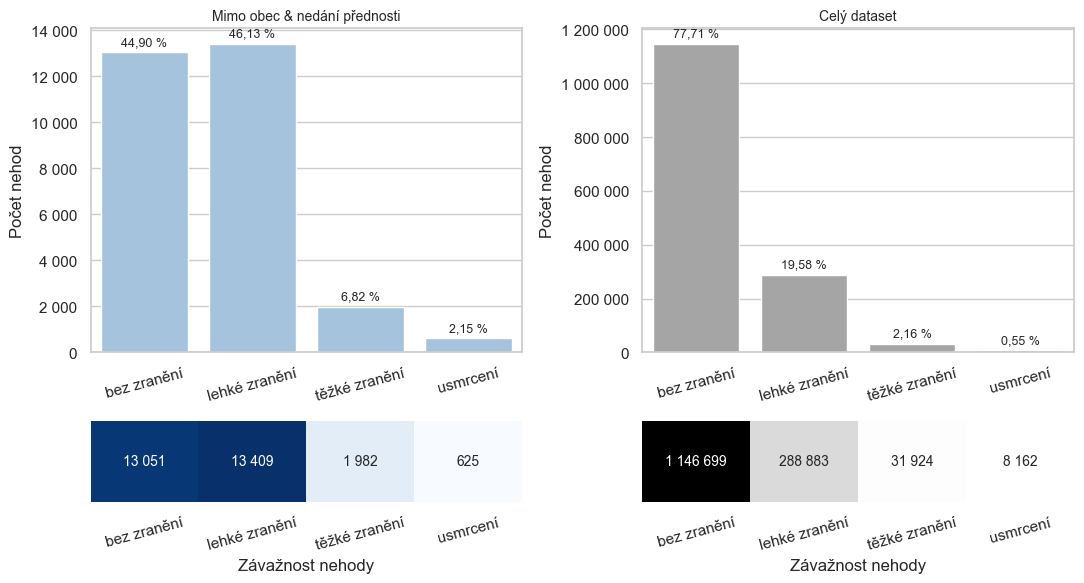

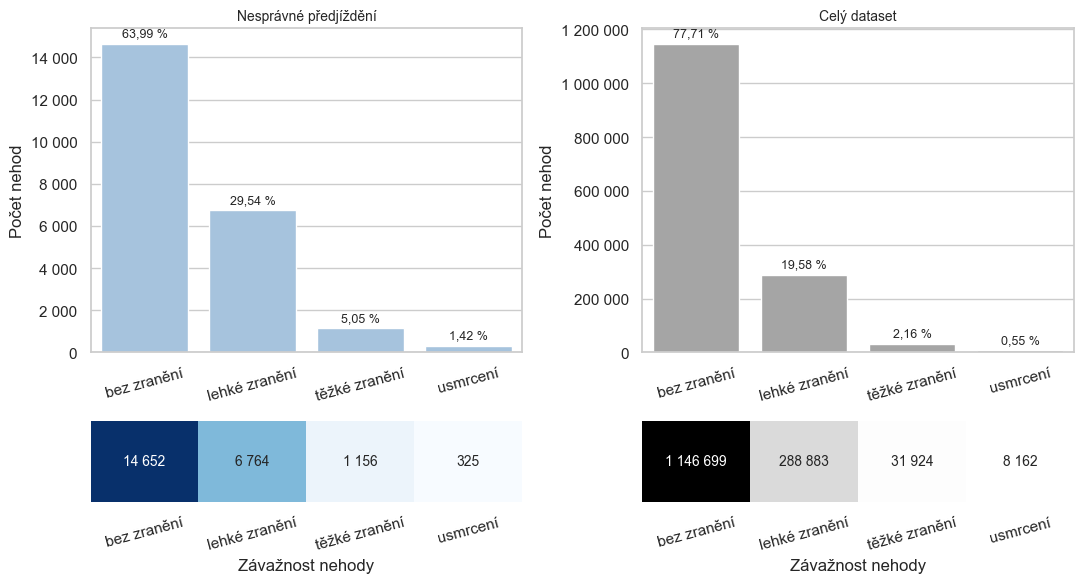

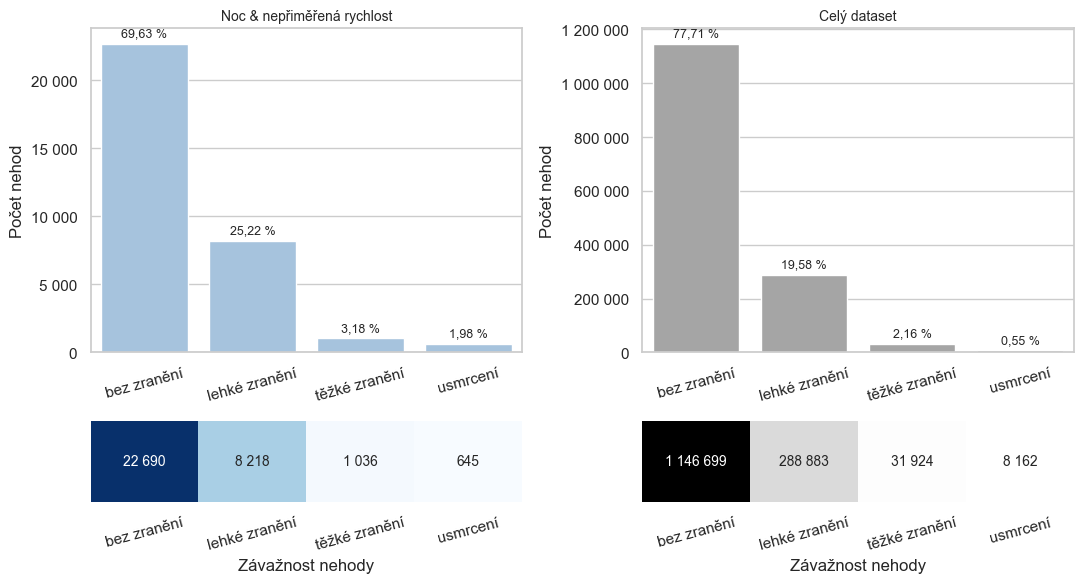

In [55]:
z2_profiles = pd.read_csv("z2_cf_profiles.csv")
severity_order = ["bez zranění", "lehké zranění", "těžké zranění", "usmrcení"]

baseline_counts = (
    df_cm_accidents["zavaznost_nehody"]
    .value_counts()
    .reindex(severity_order)
)
n_total = int(baseline_counts.sum())
baseline_n = baseline_counts.tolist()
baseline_pct = (baseline_counts / n_total * 100).tolist()

profiles_to_plot = {
    92:  ("Mimo obec & nedání přednosti",
          "Distribuce závažnosti pro pravidlo 92"),
    137: ("Nesprávné předjíždění",
          "Distribuce závažnosti pro pravidlo 137"),
    33:  ("Noc & nepřiměřená rychlost",
          "Distribuce závažnosti pro pravidlo 33"),
}

for rid, (title_label, filename) in profiles_to_plot.items():
    profile = z2_profiles[z2_profiles["rule_id"] == rid].iloc[0]
    profile_pct = [profile["bez_pct"], profile["leh_pct"], profile["tez_pct"], profile["usm_pct"]]
    n_profile = int(profile["base"])
    profile_n = [int(round(n_profile * p / 100)) for p in profile_pct]

    fig, axes = plt.subplots(2, 2, figsize=(11, 6),
                             gridspec_kw={"height_ratios": [4, 1]})

    for ax, vals_n, vals_pct, t, color in [
        (axes[0, 0], profile_n, profile_pct, title_label, "#9DC3E6"),
        (axes[0, 1], baseline_n, baseline_pct, "Celý dataset", "#A5A5A5"),
    ]:
        sns.barplot(x=severity_order, y=vals_n, color=color, ax=ax)
        ax.set_title(t, fontsize=10)
        ax.set_xlabel("")
        ax.set_ylabel("Počet nehod")
        ax.tick_params(axis="x", labelrotation=15)
        for c in ax.containers:
            labels = [f"{p:.2f} %".replace(".", ",") for p in vals_pct]
            ax.bar_label(c, labels=labels, padding=3, fontsize=9)
        ax.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f"{int(x):,}".replace(",", " ")))

    for ax, vals_n, cmap in [
        (axes[1, 0], profile_n, "Blues"),
        (axes[1, 1], baseline_n, "Greys"),
    ]:
        annot = np.array([[f"{n:,}".replace(",", " ") for n in vals_n]])
        sns.heatmap([vals_n], annot=annot, fmt="", cmap=cmap, cbar=False,
                    xticklabels=severity_order, yticklabels=False, ax=ax,
                    annot_kws={"fontsize": 10})
        ax.set_xlabel("Závažnost nehody")
        ax.tick_params(axis="x", labelrotation=15)

    save_plot(filename)